# Collect AVH Data for Analysis
The following code brings together data generated and collected by Feng, Changye, and George into a single dataframe for future analysis. Right now the focus is on transcript level information for the sandwich analysis.

TODO

    1) How to handle NAs? Can implement smarter NA handling by only removing rows that have NAs in the columns we care about
    2) Log of WER
    3) Add in pause proportion
    4) Do not use SNR for WER

## Import libraries and functions

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# import statsmodels.api as sm
# from statsmodels.regression.mixed_linear_model import MixedLM
import numpy as np
from io import StringIO
from pathlib import Path

# directory_path = Path("another_new_directory")

# directory_path.mkdir(parents=True, exist_ok=True)
# print(f"Directory '{directory_path}' ensured to exist.")
out_folder = "/edata/obdw/sandwich_analysis_data/"

In [2]:
# Import shared utilities
import sys
import importlib
sys.path.insert(0, '/home/NETID/emd5')
import avh_utils
# Reload in case the module has been updated
importlib.reload(avh_utils)
from avh_utils import decode_variable_name, data_dictionary

In [3]:
def process_uid(series: pd.SparseDtype) -> pd.Series:
    """
    Extract unique pid from file names in a pandas Series. From Changye Li

    Args:
        series (pd.Series): Series containing file names of the transcripts

    Returns:
        pd.Series: Series with processed PIDs as integers
    """
    # Split the strings and get the first element (pid part)
    pids = series.str.split('-').str[0]
    
    # Clean up the pid strings
    pids = (pids.str.rstrip('@avh')
                .str.lstrip('u')
                .str.lstrip('0')
                .astype(int))
    
    return pids

## Read in Data

In [4]:
ptcpt_baseline_path = "/edata/changye/avh-data/avh_record_baseline_kwargs.jsonl"# I wil use this file as the main
rcd_whisperx_scores_path = "/edata/feng/avh/whisperx_merged_with_manual.json" #"/edata/feng/avh/whisperx_full_cleaned.json"
rcd_snr_path = "/edata/changye/avh-new/data/snr.csv"
rcd_mos_path = "/edata/changye/avh-data/pred_mos.csv"
rcd_coh_recording_level_path = "/edata/george/debias_merged_new.csv"




In [5]:
baseline_df = pd.read_json(ptcpt_baseline_path, lines=True)
baseline_df = baseline_df.set_index("pid", drop=True).rename_axis("file")
baseline_df = baseline_df.rename(columns={"uid":"pid"})
baseline_df.shape

/tmp/ipykernel_2556716/1815851295.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  baseline_df = pd.read_json(ptcpt_baseline_path, lines=True)


ValueError: Expected object or value

In [ ]:
baseline_df = pd.read_json(ptcpt_baseline_path, lines=True)
baseline_df = baseline_df.set_index("pid", drop=True).rename_axis("file")
baseline_df = baseline_df.rename(columns={"uid":"pid"})

rcd_whisperx_scores_df = pd.read_json(rcd_whisperx_scores_path, lines=True)
rcd_whisperx_scores_df = rcd_whisperx_scores_df.set_index("file", drop=True)#.rename_axis("file")
# rcd_whisperx_scores_df["pid"] = process_uid(rcd_whisperx_scores_df.pid)


rcd_snr_df = pd.read_csv(rcd_snr_path)
rcd_snr_df = rcd_snr_df.set_index("file")
rcd_snr_df["pid"] = process_uid(rcd_snr_df.index)

rcd_mos_df = pd.read_csv(rcd_mos_path)
rcd_mos_df = pd.DataFrame(rcd_mos_df.groupby(['file_name'])['pred_mos'].mean())
rcd_mos_df["pid"] = process_uid(rcd_mos_df.index)


rcd_level_coh_df = pd.read_csv(rcd_coh_recording_level_path)# Similar to above but for recordings.
rcd_level_coh_df["file"] = rcd_level_coh_df.file.apply(lambda x: x.strip(".txt"))
rcd_level_coh_df = rcd_level_coh_df.set_index("file")
rcd_level_coh_df["pid"] = process_uid(rcd_level_coh_df.index)


In [ ]:
list(rcd_whisperx_scores_df.columns)

['segments',
 'prediction',
 'time_diffs',
 'pause_proportion',
 'pid',
 'record',
 'text',
 'audio',
 'wer',
 'cer']

In [ ]:
list(rcd_snr_df.columns)

['snr', 'pid']

In [ ]:
list(rcd_mos_df.columns)

['pred_mos', 'pid']

In [ ]:
#list(rcd_level_coh_df.columns)

In [ ]:
list(rcd_snr_df.columns)

['snr', 'pid']

In [ ]:
print("Baseline scores shape", baseline_df.shape)
print("Whisper scores shape", rcd_whisperx_scores_df.shape)
print("SNR shape", rcd_snr_df.shape)
print("MOS shape", rcd_mos_df.shape)
print("COH shape", rcd_level_coh_df.shape)

Baseline scores shape (2904, 128)
Whisper scores shape (2994, 10)
SNR shape (3003, 2)
MOS shape (2981, 2)
COH shape (3003, 133)


## Clean Data

### Check transcript file names

In [ ]:
baseline_files = set(baseline_df.index)
whisper_files = set(rcd_whisperx_scores_df.index)
snr_files = set(rcd_snr_df.index)
mos_files = set(rcd_mos_df.index)
coh_files = set(rcd_level_coh_df.index)

file_names_union = whisper_files.union(snr_files).union(mos_files).union(coh_files).union(baseline_files)
file_names_intersection = whisper_files.intersection(snr_files).intersection(mos_files).intersection(coh_files).intersection(baseline_files)
print("There are a total of {:,} file names and only {:,} at the intersection".format(len(file_names_union), len(file_names_intersection)))

There are a total of 3,007 file names and only 2,886 at the intersection


### Remove duplicated columns
Not all will be removed but this should clean it up some

In [ ]:
def remove_duplicated_columns(main_df, secondary_df, extra_cols_to_drop, protected_cols = set(["pid"])):
    """
    Description: removes duiplicated columns from secondary_df which main_df already contains
    Input:
        main_df (pandas df): dataframe
        secondary_df (pandas df): dataframe
        extra_cols_to_drop (list or set): Additional column names to drop from extra cols. Useful if you know cols
            are duplicates but with different names
        protected_cols (list or set): Columns not to drop.  THIS IS NO LONGER USED AND DOES NOT WORK ANYWAY
    Output:
        updated_df: (pandas df): same as secondary_df, but with duplicated columns removed
    TODO
        1)
    """

    intersection_columns = set(main_df).intersection(secondary_df).union(extra_cols_to_drop)
    print(intersection_columns)
    print("cols dropped", len(intersection_columns))
    updated_df = secondary_df.drop(intersection_columns, axis=1)
    print("new shape", updated_df.shape)
    return(updated_df)

In [ ]:
coh_cols_to_drop = ['contact',
 'temper-outbursts',
 'feeling-blocked',
 'worrying-too-much',
 'easily-hurt',
 'feeling-watched',
 'feeling-tense',
 'heavy-feelings-in-arms-legs',
 'feeling-nervous',
 'feeling-lonely',
 'frequency',
 'bad-voices',
 'volume-of-voices',
 'voices-length',
 'interference-in-activities',
 'distressing-voices',
 'worthless-useless-voices',
 'clarity-of-voices',
 'follow-voices-orders',
 'time-of-day-of-voices',
 'social-situations',
 'where-are-the-voices',
 'typical-week',
 'if-no-explanation',
 'work-school-disruption',
 'social-leisure-disruption',
 'home-family-disruption',
 'school-work-missed',
 'less-productive-days',
#  'not-worked-for-other-reasons',# not removed since this is one George suggested to keep
 'little-interest-or-pleasure',
 'feeling-depressed',
 'trouble-sleeping',
 'feeling-tired',
 'appetite',
 'feeling-bad-about-self',
 'trouble-concentrating',
 'slow-fast-speaking',
 'suicidal-thoughts',
 'impact-on-your-life', 'text']

In [ ]:
print("Removing columns from coh df")
rcd_level_coh_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_level_coh_df, extra_cols_to_drop=coh_cols_to_drop)
print("\n\nRemoving columns from whisperx df")
rcd_whisperx_scores_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_whisperx_scores_df, extra_cols_to_drop=["text"])
print("\n\nRemoving columns from mos df")
rcd_mos_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_mos_df, extra_cols_to_drop=[])
print("\n\nRemoving columns from snr df")
rcd_snr_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_snr_df, extra_cols_to_drop=[])

Removing columns from coh df
{'worthless-useless-voices', 'days of data', 'feeling-bad-about-self', 'suicidal-thoughts', 'sexuality', 'volume-of-voices', 'substances-used', 'comp_q4', 'feeling-tense', 'social-media', 'wearable-tech', 'feeling-lonely', 'distressing-voices', 'tablet', 'comp_q1', 'appetite', 'clarity-of-voices', 'type-of-treatments', 'verify-hearing-voices', 'how-long', 'phone', 'interference-in-activities', 'text', 'gender', 'feeling-watched', 'voices-length', 'feeling-nervous', 'home-family-disruption', 'bad-voices', 'feeling-depressed', 'smartphone', 'frequency', 'in_person', 'feeling-blocked', 'trouble-concentrating', 'follow-voices-orders', 'who-knows', 'diagnoses', 'how-often', 'ah_freq', 'age', 'worrying-too-much', 'hispanic', 'comp_q2', 'social-leisure-disruption', 'social-situations', 'employment-status', 'temper-outbursts', 'contact', 'school-work-missed', 'feeling-tired', 'work-school-disruption', 'location', 'impact-on-your-life', 'less-productive-days', 'easi

## Merge Data

In [ ]:
main_analysis_df = pd.concat([baseline_df, rcd_whisperx_scores_df, rcd_snr_df, rcd_mos_df, rcd_level_coh_df], axis=1, join="inner")
assert main_analysis_df.shape[0] == len(file_names_intersection)
print(main_analysis_df.shape)
print(main_analysis_df.columns)


(2886, 189)
Index(['pid', 'record', 'transcription', 'audio', 'prediction', 'wer', 'cer',
       'record_date', 'in_person', 'days of data',
       ...
       'density', 'degree_average', 'degree_std', 'L1', 'id', 'account_id',
       'account_status', 'page_progress', 'Tracking',
       'not-worked-for-other-reasons'],
      dtype='object', length=189)


In [ ]:
# Check that each participant has consistent location data across all transcripts
# Assumes you have a DataFrame with 'pid' as participant ID and location columns (e.g., 'PrimaryRUCA', 'RPL_THEMES', etc.)

#ToD0: location isn't merged in this high, move cell after location merge
location_columns = [
    'PrimaryRUCA', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4',
    'doctor_count', 'pharmacy_count', 'hospital_count', 'park_count', 'bus_station_count', 'supermarket_count', 'cluster'
]

# Replace 'main_analysis_df' with the actual DataFrame variable name containing these columns
df_location = main_analysis_df[['pid'] + [col for col in location_columns if col in main_analysis_df.columns]].copy()

# Group by participant and check for unique location rows
inconsistent_pids = []
for pid, group in df_location.groupby('pid'):
    # Drop duplicate location rows for this participant
    unique_locs = group[[col for col in location_columns if col in group.columns]].drop_duplicates()
    if len(unique_locs) > 1:
        inconsistent_pids.append(pid)
    if pid == 8: 
        print(unique_locs)


if inconsistent_pids:
    print(f"WARNING: Found {len(inconsistent_pids)} participants with inconsistent location data across transcripts.")
    print("Participant IDs with inconsistent location data:", inconsistent_pids)
else:
    print("All participants have consistent location data across transcripts.")

#ToDo: moved this code around, doesn't work
# Have to redo the above code to check for consistency of location data across transcripts. I moved it around and it doesn't work anymore, not sure why.


Empty DataFrame
Columns: []
Index: [u00000008@avh-20180311-1, u00000008@avh-20180329-1]
Participant IDs with inconsistent location data: [3, 8, 50, 55, 57, 79, 88, 90, 105, 115, 118, 123, 134, 162, 170, 235, 240, 253, 275, 281, 305, 313, 333, 341, 366, 373, 374, 382, 383, 392, 396, 409, 413, 441, 443, 448, 449, 450, 457, 472, 478, 485, 500, 509, 518, 520, 564, 581, 600, 606, 649, 652, 669, 677, 681, 688, 703, 705, 706, 739, 747, 768, 796, 802, 803, 814, 815, 827, 831, 844, 847, 848, 866, 879, 896, 919, 928, 933, 949, 960, 962, 963, 967, 993, 1008, 1010, 1017, 1020, 1035, 1037, 1042, 1063, 1081, 1088, 1155, 1166, 1172, 1179, 1204, 1206, 1211, 1228, 1247, 1248, 1251, 1252, 1261, 1283, 1293, 1295, 1296, 1319, 1322, 1325, 1350, 1351, 1352, 1358, 1363, 1377, 1396, 1405, 1425, 1435, 1441, 1442, 1450, 1460, 1461, 1489, 1493, 1499, 1501, 1515, 1517, 1524, 1529, 1537, 1553, 1558, 1574, 1580, 1595, 1597, 1607, 1621, 1639, 1643, 1644, 1651, 1665, 1679, 1682, 1683, 1686, 1690, 1691, 1706, 1714, 17

In [ ]:
# Explore a few participants with inconsistent location data across transcripts
# Pick a few participant IDs from inconsistent_pids
example_pids = inconsistent_pids[:3]  # You can change the number or pick specific IDs

for pid in example_pids:
    print(f"\nParticipant {pid} - Location data across transcripts:")
    display(df_location[df_location['pid'] == pid])
    # Show unique location rows for this participant
    unique_locs = df_location[df_location['pid'] == pid][[col for col in location_columns if col in df_location.columns]].drop_duplicates()
    print(f"Unique location rows for participant {pid}:")
    display(unique_locs)



Participant 3 - Location data across transcripts:


,pid
u00000003@avh-20180409-1,3
u00000003@avh-20180316-1,3
u00000003@avh-20180413-2,3
u00000003@avh-20180308-1,3
u00000003@avh-20180331-1,3
u00000003@avh-20180329-1,3
u00000003@avh-20180402-1,3
u00000003@avh-20180413-1,3
u00000003@avh-20180309-1,3
u00000003@avh-20180315-1,3


Unique location rows for participant 3:


""
u00000003@avh-20180409-1
u00000003@avh-20180316-1
u00000003@avh-20180413-2
u00000003@avh-20180308-1
u00000003@avh-20180331-1
u00000003@avh-20180329-1
u00000003@avh-20180402-1
u00000003@avh-20180413-1
u00000003@avh-20180309-1
u00000003@avh-20180315-1



Participant 8 - Location data across transcripts:


...

""
u00000008@avh-20180311-1
u00000008@avh-20180329-1



Participant 50 - Location data across transcripts:


,pid
u00000050@avh-20180414-3,50
u00000050@avh-20180331-1,50
u00000050@avh-20180329-1,50
u00000050@avh-20180406-3,50
u00000050@avh-20180324-2,50
u00000050@avh-20180328-3,50
u00000050@avh-20180417-1,50
u00000050@avh-20180406-1,50
u00000050@avh-20180403-2,50
u00000050@avh-20180409-1,50


Unique location rows for participant 50:


""
u00000050@avh-20180414-3
u00000050@avh-20180331-1
u00000050@avh-20180329-1
u00000050@avh-20180406-3
u00000050@avh-20180324-2
u00000050@avh-20180328-3
u00000050@avh-20180417-1
u00000050@avh-20180406-1
u00000050@avh-20180403-2
u00000050@avh-20180409-1


## Remove NA
I am ignoring certain columns I do not expect to use. Like many of the coherence columns. Otherwise we would be dropping many columns with NAs that we would never use.

In [ ]:
columns2ignore_na = ["not-worked-for-other-reasons"]
for column_name in main_analysis_df.columns:
    if "Coherence" in column_name and column_name != "sentCoherenceSentBertCumulativeCentroid":# the one we care about is sentCoherenceSentBertCumulativeCentroid
        columns2ignore_na.append(column_name)
# Code below just to look at columns with na
#  for x, y in zip(main_analysis_df.columns, list(main_analysis_df.isna().sum())):
#     if x in columns2ignore_na:
#         continue
#     print(x, y)
main_analysis_df.drop(columns2ignore_na, axis=1, inplace=True)
main_analysis_df.dropna(axis=0, inplace=True)
main_analysis_df


,pid,record,transcription,audio,prediction,wer,cer,record_date,in_person,days of data,...,LSC,density,degree_average,degree_std,L1,id,account_id,account_status,page_progress,Tracking
u00001870@avh-20190708-17,1870,17,"In addition, I've had tons of problems with my...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,"In addition, I've had tons of problems with my...",7.529412,3.307304,2019-07-08T23:04:00.000,1.0,31.0,...,206,0.010040,4.116505,4.408291,0,1870,1870,study_finished,downloading,FINISHED
u00001870@avh-20190707-11,1870,11,"And so initially, this would have been 2017. U...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,"And, so, initially, when this would have been ...",7.915567,4.319762,2019-07-07T12:53:00.000,1.0,31.0,...,185,0.010985,4.064516,4.837814,0,1870,1870,study_finished,downloading,FINISHED
u00001553@avh-20190207-3,1553,3,Still hearing the whispers. Some forceful talk...,/edata/avh_data/Audio_dump/u00001553@avh-20190...,Still hearing the whispers. Some forceful talk...,26.666667,9.973753,2019-02-07T18:58:00.000,1.0,31.0,...,52,0.020360,2.483871,1.456265,1,1553,1553,study_finished,downloading,FINISHED
u00001788@avh-20190415-1,1788,1,I'm here. The voices try and tell me some thin...,/edata/avh_data/Audio_dump/u00001788@avh-20190...,"Hi, I'm here. The voice is trying to tell me s...",41.379310,27.118644,2019-04-15T06:06:00.000,2.0,25.0,...,19,0.060606,2.545455,1.339175,0,1788,1788,app_installed,downloading,FINISHED
u00002319@avh-20190901-1,2319,1,The voices today are the same as yesterday tel...,/edata/avh_data/Audio_dump/u00002319@avh-20190...,"The voices today are the same as yesterday, te...",0.000000,0.000000,2019-09-01T07:55:00.000,1.0,31.0,...,43,0.027211,2.612245,1.562524,1,2319,2319,study_finished,downloading,FINISHED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u00001870@avh-20190708-15,1870,15,"The problem that I was having, uh, I mean, I h...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,The problem that i was having a...I have long ...,27.950311,15.113452,2019-07-08T22:58:00.000,1.0,31.0,...,215,0.010389,4.446512,5.968575,1,1870,1870,study_finished,downloading,FINISHED
u00000866@avh-20181001-3,866,3,"Um, this is my third recording of the evening....",/edata/avh_data/Audio_dump/u00000866@avh-20181...,"Um, this is my third recording of the evening,...",39.733840,28.162772,2018-10-01T19:11:00.000,1.0,31.0,...,223,0.010605,4.708520,6.451632,0,866,866,study_finished,downloading,FINISHED
u00001425@avh-20190127-1,1425,1,"Good morning. Uh, I didn't hear the voices whe...",/edata/avh_data/Audio_dump/u00001425@avh-20190...,"Good morning. Uh, I didn't hear the voices whe...",5.405405,3.499079,2019-01-27T09:26:00.000,1.0,33.0,...,60,0.024876,3.283582,2.380305,0,1425,1425,app_installed,downloading,FINISHED
u00002182@avh-20190813-3,2182,3,"I believe that I heard God say , but I heard G...",/edata/avh_data/Audio_dump/u00002182@avh-20190...,"I believe that I heard God say, in previous, I...",128.571429,126.984127,2019-08-13T18:42:00.000,1.0,31.0,...,19,0.060606,2.545455,1.269476,0,2182,2182,study_finished,downloading,FINISHED


In [ ]:
# Display the main_analysis_df to inspect the data
#main_analysis_df

In [ ]:
main_analysis_df.to_csv(out_folder + "main_merged_sandwich_analysis_data.csv")

In [ ]:
temp = pd.read_csv(out_folder + "main_merged_sandwich_analysis_data.csv", index_col=0)

In [ ]:
temp

,pid,record,transcription,audio,prediction,wer,cer,record_date,in_person,days of data,...,LSC,density,degree_average,degree_std,L1,id,account_id,account_status,page_progress,Tracking
u00001870@avh-20190708-17,1870,17,"In addition, I've had tons of problems with my...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,"In addition, I've had tons of problems with my...",7.529412,3.307304,2019-07-08T23:04:00.000,1.0,31.0,...,206,0.010040,4.116505,4.408291,0,1870,1870,study_finished,downloading,FINISHED
u00001870@avh-20190707-11,1870,11,"And so initially, this would have been 2017. U...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,"And, so, initially, when this would have been ...",7.915567,4.319762,2019-07-07T12:53:00.000,1.0,31.0,...,185,0.010985,4.064516,4.837814,0,1870,1870,study_finished,downloading,FINISHED
u00001553@avh-20190207-3,1553,3,Still hearing the whispers. Some forceful talk...,/edata/avh_data/Audio_dump/u00001553@avh-20190...,Still hearing the whispers. Some forceful talk...,26.666667,9.973753,2019-02-07T18:58:00.000,1.0,31.0,...,52,0.020360,2.483871,1.456265,1,1553,1553,study_finished,downloading,FINISHED
u00001788@avh-20190415-1,1788,1,I'm here. The voices try and tell me some thin...,/edata/avh_data/Audio_dump/u00001788@avh-20190...,"Hi, I'm here. The voice is trying to tell me s...",41.379310,27.118644,2019-04-15T06:06:00.000,2.0,25.0,...,19,0.060606,2.545455,1.339175,0,1788,1788,app_installed,downloading,FINISHED
u00002319@avh-20190901-1,2319,1,The voices today are the same as yesterday tel...,/edata/avh_data/Audio_dump/u00002319@avh-20190...,"The voices today are the same as yesterday, te...",0.000000,0.000000,2019-09-01T07:55:00.000,1.0,31.0,...,43,0.027211,2.612245,1.562524,1,2319,2319,study_finished,downloading,FINISHED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u00001870@avh-20190708-15,1870,15,"The problem that I was having, uh, I mean, I h...",/edata/avh_data/Audio_dump/u00001870@avh-20190...,The problem that i was having a...I have long ...,27.950311,15.113452,2019-07-08T22:58:00.000,1.0,31.0,...,215,0.010389,4.446512,5.968575,1,1870,1870,study_finished,downloading,FINISHED
u00000866@avh-20181001-3,866,3,"Um, this is my third recording of the evening....",/edata/avh_data/Audio_dump/u00000866@avh-20181...,"Um, this is my third recording of the evening,...",39.733840,28.162772,2018-10-01T19:11:00.000,1.0,31.0,...,223,0.010605,4.708520,6.451632,0,866,866,study_finished,downloading,FINISHED
u00001425@avh-20190127-1,1425,1,"Good morning. Uh, I didn't hear the voices whe...",/edata/avh_data/Audio_dump/u00001425@avh-20190...,"Good morning. Uh, I didn't hear the voices whe...",5.405405,3.499079,2019-01-27T09:26:00.000,1.0,33.0,...,60,0.024876,3.283582,2.380305,0,1425,1425,app_installed,downloading,FINISHED
u00002182@avh-20190813-3,2182,3,"I believe that I heard God say , but I heard G...",/edata/avh_data/Audio_dump/u00002182@avh-20190...,"I believe that I heard God say, in previous, I...",128.571429,126.984127,2019-08-13T18:42:00.000,1.0,31.0,...,19,0.060606,2.545455,1.269476,0,2182,2182,study_finished,downloading,FINISHED


In [ ]:
main_analysis_df.shape

(2863, 153)

## Identify Features for Analysis
The next step is to identify subsets of features to use for sandwich analysis. Listing the features and response variable out should not be hard for each analysis. Removing nan values will depend more on the response variable I believe, since nan categorical variables can be coded up in one-hot encoding. However it might be wise to remove rows with any nan values.

### Options for final cleaning

1) Remove nan values from each dataframe on a per analysis criteria
2) Remove nan values from the overall dataframe so each analysis is working with the same dataframe.
3) A hybrid approach of the above where rows are removed based off of nan values in the features from the overall dataframe and then nan values are removed in the response variable on a per analysis criteria.

## Feature Engineering
As of now, this is only one-hot encoding code I have from the previous analysis

In [ ]:
list(main_analysis_df.columns)

['pid',
 'record',
 'transcription',
 'audio',
 'prediction',
 'wer',
 'cer',
 'record_date',
 'in_person',
 'days of data',
 'audio diary entries',
 'age',
 'gender',
 'phone',
 'data_plan',
 'ah_freq',
 'location',
 'availability',
 'future_contact',
 'comp_q1',
 'comp_q2',
 'comp_q3',
 'comp_q4',
 'comp_q5',
 'race',
 'hispanic',
 'marital-status',
 'sexuality',
 'education',
 'employment-status',
 'living-status',
 'basic-cell',
 'smartphone',
 'tablet',
 'computer',
 'wearable-tech',
 'email',
 'social-media',
 'verify-hearing-voices',
 'how-often',
 'how-long',
 'diagnoses',
 'dx-alzheimers-parkinsons',
 'dx-bipolar-disorder',
 'dx-depression',
 'dx-tbi',
 'dx-migraines',
 'dx-schizoaffective-disorder',
 'dx-schizophrenia',
 'dx-ptsd',
 'dx-substance-use',
 'dx-seizures',
 'dx-none-of-the-above',
 'dx-other',
 'used-treatment',
 'type-of-treatments',
 'tx-one-on-one',
 'tx-online',
 'tx-group',
 'tx-partial-hospitalization',
 'tx-alcohol-drug-rehab',
 'tx-telepsychiatry',
 'tx-re

In [ ]:
# Loop through all columns in X_basic_plus_clin_sdh_location_encoded except 'WER' and run a simple linear regression (WER ~ variable)
# Univariate regression results will be used to identify which variables are significantly associated with WER, 
# and to understand the direction and magnitude of these associations. 
# This will help us identify potential predictors of WER and inform our multivariate regression model later on.
import pandas as pd
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Load the data if not already loaded
data_path = '/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_encoded.csv'
df = pd.read_csv(data_path)

# Identify the WER column (case-insensitive)
wer_col = [col for col in df.columns if col.lower() == 'wer']
if not wer_col:
    raise ValueError('WER column not found in the data.')
wer_col = wer_col[0]

# Loop through all columns except WER
# ToDo: Indiviual Variables
# Bar Plots = green coding if significant, red if not, and show the beta values on the plot. This is important for understanding the direction and magnitude of the relationship, and for visually communicating the results to others.
# ToDo: add the sandwich correction to the regression to account for non-independence of observations within participants. This is important because we have multiple transcripts per participant, and we want to make sure our standard errors are correct.
regression_results = {}
for col in df.columns:
    if col == wer_col or col == 'pid':
        continue
    # Drop NA for the current variable and WER
    temp = df[[wer_col, col, 'pid']].dropna()
    if temp.empty:
        continue  # Skip if there's no data after dropping NA
    
    vals = temp[col]  # might be Series OR DataFrame
    if isinstance(vals, pd.DataFrame):
        vals = vals.iloc[:, 0]

    nuniq = vals.nunique(dropna=True)

    # If vals is a DataFrame, nuniq is a Series (one per column)
    if isinstance(nuniq, pd.Series):
        if (nuniq < 2).any():   # or .all(), depending on intent
            continue
    else:
        if nuniq < 2:
            continue
    # Need at least 2 clusters for clustered SEs.
    pid = temp.loc[:, 'pid']
    if isinstance(pid, pd.DataFrame):
        pid = pid.iloc[:, 0]   # take first pid column
    if pid.nunique(dropna=True) < 2:
        continue

    #if temp['pid'].nunique(dropna=True) < 2:
    #    continue  # Skip if there's not enough variation in 'pid' for clustering, only 1 pid statsmodel will throw errors

    X = sm.add_constant(vals)
    y = temp[wer_col]
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': pid})
    regression_results[col] = model  # Store the model object, not the summary
    print(f"\n{'='*40}\nRegression: {wer_col} ~ {col}\n{'='*40}")

    #print(model.summary())
    try:
        print(model.summary())
    except Exception as e:
        # coef = model.params.get(col, float("nan"))
        # pval = model.pvalues.get(col, float("nan"))
        # se   = model.bse.get(col, float("nan"))
        # tval = model.tvalues.get(col, float("nan"))
        print(f"[summary() failed: {str(e)}] ")
            # f"{wer_col} ~ {col} | N={int(model.nobs)} | "
            # f"beta={coef:.4g} | SE={se:.4g} | t={tval:.3g} | p={pval:.3g} | "
            # f"R2={model.rsquared:.3g}")




# regression_results now contains the model for each variable
print(regression_results)

# Summarize significant variables from the regression results
summary = []
for col, model in regression_results.items():
    # Make sure model has pvalues and at least 2 elements (const + variable)
    if hasattr(model, 'pvalues') and len(model.pvalues) > 1:
        pval = model.pvalues[1]
        coef = model.params[1]
    else:
        pval = None
        coef = None
    n = int(model.nobs) if hasattr(model, 'nobs') else None
    r_squared = model.rsquared if hasattr(model, 'rsquared') else None
    adj_r_squared = model.rsquared_adj if hasattr(model, 'rsquared_adj') else None
    f_stat = model.fvalue if hasattr(model, 'fvalue') else None
    f_pval = model.f_pvalue if hasattr(model, 'f_pvalue') else None
    
    summary.append({
        'Variable': col, 
        'Coefficient': coef,
        'p-value': pval, 
        'N': n,
        'R-squared': r_squared,
        'Adj R-squared': adj_r_squared,
        'F-statistic': f_stat,
        'F p-value': f_pval
    })


# Add decoded variable names for better readability
# Use a safe wrapper to handle any decoding errors
# ToDo: This was a copy / paste from above, remove
def safe_decode(var_name):
    try:
        return decode_variable_name(var_name)
    except Exception as e:
        # If decoding fails, return the original variable name
        return var_name
        
# Create DataFrame
summary_df = pd.DataFrame(summary)
summary_df['Variable_Decoded'] = summary_df['Variable'].apply(safe_decode)

print("Summary of regression results run for each variable univariate:")
print(summary_df)
summary_df.to_csv("Univariate_Regression_from_X_basic_plus_clin_sdh_location_encoded.csv", index=False)


# Filter for significant variables (p < 0.05)
significant_vars = summary_df[summary_df['p-value'] < 0.05].sort_values('p-value')

#ToDo: update N, this is calculating wrong
#ToD: show the beta values, the coefficient, not just the p-value. This is important for understanding the direction and magnitude of the relationship.
#ToDo: we want to show if the coefficient is positive or negative, to understand the direction of the relationship. This is important for interpreting the results and understanding which variables are associated with higher or lower WER.
#ToDo: send Oliver a link later with the figures and put it in OneDrive, and also share the code and data so he can run it himself and understand it better.

# Display the significant variables
print('Significant variables (p < 0.05):')
print(significant_vars)
significant_vars



Regression: wer ~ Unnamed: 0
                            OLS Regression Results                            
Dep. Variable:                    wer   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.7389
Date:                Tue, 03 Mar 2026   Prob (F-statistic):              0.391
Time:                        22:51:19   Log-Likelihood:                -18064.
No. Observations:                2863   AIC:                         3.613e+04
Df Residuals:                    2861   BIC:                         3.614e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5824 

/tmp/ipykernel_1045630/3319978677.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = model.pvalues[1]
/tmp/ipykernel_1045630/3319978677.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = model.params[1]


,Variable,Coefficient,p-value,N,R-squared,Adj R-squared,F-statistic,F p-value,Variable_Decoded
8,gender_4.0,-16.589659,1.841500e-08,2863,0.000022,-0.000328,31.654894,4.544651e-08,Gender: Transgender (F to M)
9,gender_5.0,16.158310,4.293077e-08,2863,0.000036,-0.000314,30.012330,9.724207e-08,Gender: Other
45,PrimaryRUCA_4.0,-15.626193,1.080845e-06,2863,0.000379,0.000030,23.778474,1.834063e-06,Primaryruca: Micropolitan Core
49,PrimaryRUCA_8.0,-14.236248,1.783150e-06,2863,0.000048,-0.000302,22.815573,2.909067e-06,Primaryruca: Small Town High Commuting
44,PrimaryRUCA_3.0,-13.065399,5.265324e-05,2863,0.000149,-0.000200,16.350105,6.849237e-05,Primaryruca: Metropolitan Low Commuting
48,PrimaryRUCA_7.0,-11.209188,1.462232e-04,2863,0.000017,-0.000332,14.420228,1.801021e-04,Primaryruca: Small Town Core
7,gender_3.0,-11.129101,3.234036e-04,2863,0.000341,-0.000009,12.929735,3.834853e-04,Gender: Transgender (M to F)
16,snr,-1.360427,3.630045e-03,2863,0.005787,0.005439,8.460187,3.927461e-03,Signal-to-Noise Ratio (SNR)
51,PrimaryRUCA_10.0,-9.124373,5.679486e-03,2863,0.000242,-0.000107,7.649284,6.065518e-03,Primaryruca: Rural
38,pharmacy_count,0.614355,8.083636e-03,2419,0.000546,0.000132,7.014851,8.674831e-03,Pharmacy Count


In [ ]:
Y_WER = pd.concat([main_analysis_df.wer, np.log(main_analysis_df.wer + 1e-8)],axis =1, keys = ["wer", "log_wer"]) #main_analysis_df.wer
Y_COH = main_analysis_df.sentCoherenceSentBertCumulativeCentroid # Need to check if this is still the best one to use.

In [ ]:
binmappers = {
                "education":{
                    2.0: 1.0,# 1.0 means up to codes for education - data dictionary for things like HS diploma, College degree, etc.
                    3.0: 1.0,
                    4.0: 1.0,
                    5.0: 2.0,
                    6.0: 2.0,
                    7.0: 3.0,
                    8.0: 3.0,
                    np.nan:np.nan,
                }
           }
def bin_age(age):
    """
    Description: Bins all age value from an pandas series. To be used in an apply function
    Inputs:
        ages (float): Float age
    Outputs:
        age_bin (int): Int category for age bin
    TODO:
        1)
    """
    if np.isnan(age):
        age_bin = 0.0
    elif age == 999.0:
        age_bin = 0.0
    # elif age < 18.0:
    #     age_bin = 0.0
    elif age < 30.0:
        age_bin = 1.0
    elif age < 45.0:
        age_bin = 2.0
    elif age < 65.0:
        age_bin = 3.0
    else:
        age_bin = 4.0
    return(age_bin)

def replaced_age_with_binning(df):
    """
    Description: Wrapper for bin_age where the original age columns is dropped
    Inputs:
        df (pandas df): Pandas dataframe
    Outputs:
        df (pandas df): Same as input, but with age removed, and binned_age added
    TODO:
        1)
    """
    temp_df = df.copy(deep=True)
    temp_df["binned_age"] = temp_df.age.apply(lambda x: bin_age(x))
    temp_df.drop("age", axis=1, inplace=True)
    return(temp_df)
def bin_substance_use(data_df):
    """
    Decription: Bins a participants substance use. Only done for heroin and opioids
    Inputs:
         data_df (pandas DF): Dataframe containing substance use columns below
            "opioids","marijuana","alcohol","steroids","cocaine","heroin","nicotine","meth","ketamine","acid","bath-salts"
    Outputs:
    TODO
        1)
    """

    data_copy_df = data_df.copy(deep=True)
    # all_types = ["opioids","marijuana","alcohol","steroids","cocaine","heroin","nicotine","meth","ketamine","acid","bath-salts"]
    substances_of_interest = ["opioids","heroin"]
    # type_2 = ["cocaine","heroin","nicotine","meth","ketamine","acid","bath-salts"]
    data_copy_df.loc[:,substances_of_interest] = pd.DataFrame(data_copy_df.loc[:,substances_of_interest] == 1, dtype=np.float64)
    opiods_opiates_1_use = pd.Series(data_copy_df.loc[:,substances_of_interest].sum(axis=1) > 1, dtype=np.float64)
    data_copy_df.drop(labels = substances_of_interest, axis = 1, inplace = True)
    data_copy_df["opioids-opiates"] = opiods_opiates_1_use
    return(data_copy_df)
def one_hot_encode(df, cols2encode):
    """
    Description: Encodes the specified columns into one hot encoding.
    Inputs:
        df (pandas df): Dataframe with the columns to encode. Can have more.
        cls2encode (list): List of column names.
    Outputs:
        one_hot_encoded_df (pandas df): one hot encoded dataframe. 
    TODO:
        1)
    """
    enc = OneHotEncoder(drop="first")
    enc.fit(df[cols2encode])# you will have access to feature names with get_feature_names_out() 
    print(enc.categories_)
    print(enc.get_feature_names_out())
    one_hot_encoded_df =  pd.DataFrame(enc.transform(df[cols2encode]).toarray(), columns = enc.get_feature_names_out())
    one_hot_encoded_df = one_hot_encoded_df.set_index(df.index)
    return(one_hot_encoded_df)
    # X = minimum_analysis_df.drop(["race", "gender", "binned_age"], axis=1)
    # X_min_analysis = pd.concat([X, X_one_hot, Y_WER, Y_COH], axis=1, join="inner", ignore_index=False)

### Create minimum analysis data: Basic
with race, age, and gender.

In [ ]:
cols2encode=["race", "gender", "binned_age"]
# X_temp = X_temp.replace(binmappers)# Mapping education to higher level categories
# X_temp.rename(columns={"education":"education_binned"},inplace=True)
minimum_analysis_df = replaced_age_with_binning(main_analysis_df)
minimum_analysis_df = minimum_analysis_df.loc[:,cols2encode + ["pid"]]
# minimum_analysis_df
cols2encode=["race", "gender", "binned_age"]
X_one_hot = one_hot_encode(df=minimum_analysis_df, cols2encode=cols2encode)
X = minimum_analysis_df.drop(cols2encode, axis=1)
X_min_analysis = pd.concat([X, X_one_hot, Y_WER, Y_COH], axis=1, join="inner", ignore_index=False)
X_min_analysis.to_csv(out_folder + "basic_analysis.csv")
X_min_analysis


[array([  1.,   2.,   4.,   5.,   6., 999.]), array([1., 2., 3., 4., 5.]), array([0., 1., 2., 3., 4.])]
['race_2.0' 'race_4.0' 'race_5.0' 'race_6.0' 'race_999.0' 'gender_2.0'
 'gender_3.0' 'gender_4.0' 'gender_5.0' 'binned_age_1.0' 'binned_age_2.0'
 'binned_age_3.0' 'binned_age_4.0']


,pid,race_2.0,race_4.0,race_5.0,race_6.0,race_999.0,gender_2.0,gender_3.0,gender_4.0,gender_5.0,binned_age_1.0,binned_age_2.0,binned_age_3.0,binned_age_4.0,wer,log_wer,sentCoherenceSentBertCumulativeCentroid
u00001870@avh-20190708-17,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.529412,2.018817,0.062340
u00001870@avh-20190707-11,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.915567,2.068831,0.283842
u00001553@avh-20190207-3,1553,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,26.666667,3.283414,0.488357
u00001788@avh-20190415-1,1788,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,41.379310,3.722781,0.698150
u00002319@avh-20190901-1,2319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,-18.420681,0.783950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u00001870@avh-20190708-15,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27.950311,3.330428,0.241492
u00000866@avh-20181001-3,866,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39.733840,3.682203,0.166712
u00001425@avh-20190127-1,1425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.405405,1.687399,0.391968
u00002182@avh-20190813-3,2182,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,128.571429,4.856485,0.700575


### Create analysis data: Basic+
Everything in Basic with MOS and SNR added

In [ ]:
X_basic_plus = pd.concat([X_min_analysis, main_analysis_df.loc[:, ["snr", "pred_mos", "pause_proportion"]]], axis=1, join="inner", ignore_index=False)
assert X_basic_plus.shape[0] == X_min_analysis.shape[0], "Seem to have lost some columns during the join"
X_basic_plus.to_csv(out_folder + "basic_plus_analysis.csv")
X_basic_plus

,pid,race_2.0,race_4.0,race_5.0,race_6.0,race_999.0,gender_2.0,gender_3.0,gender_4.0,gender_5.0,binned_age_1.0,binned_age_2.0,binned_age_3.0,binned_age_4.0,wer,log_wer,sentCoherenceSentBertCumulativeCentroid,snr,pred_mos,pause_proportion
u00001870@avh-20190708-17,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.529412,2.018817,0.062340,5.375672,3.936099,0.083113
u00001870@avh-20190707-11,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.915567,2.068831,0.283842,5.239416,4.195542,0.051594
u00001553@avh-20190207-3,1553,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,26.666667,3.283414,0.488357,11.164604,4.162455,0.252369
u00001788@avh-20190415-1,1788,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,41.379310,3.722781,0.698150,9.495262,2.420873,0.424867
u00002319@avh-20190901-1,2319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,-18.420681,0.783950,14.463228,3.313525,0.089726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u00001870@avh-20190708-15,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27.950311,3.330428,0.241492,3.002743,4.257866,0.029134
u00000866@avh-20181001-3,866,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39.733840,3.682203,0.166712,7.682102,4.195727,0.085740
u00001425@avh-20190127-1,1425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.405405,1.687399,0.391968,1.235781,4.747826,0.091976
u00002182@avh-20190813-3,2182,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,128.571429,4.856485,0.700575,3.069747,1.750710,0.086136


### Create analysis data: Basic+ Clinical
Everything in Basic+ with the additions of phq9 total, hpsvq total, scl global average

In [ ]:
main_analysis_df.loc[:, ["phq9-total", "hpsvq-total-score", "scl-avg-global-score"]]

,phq9-total,hpsvq-total-score,scl-avg-global-score
u00001870@avh-20190708-17,10.0,31.0,2.444
u00001870@avh-20190707-11,10.0,31.0,2.444
u00001553@avh-20190207-3,24.0,22.0,3.222
u00001788@avh-20190415-1,22.0,21.0,1.556
u00002319@avh-20190901-1,18.0,18.0,1.889
...,...,...,...
u00001870@avh-20190708-15,10.0,31.0,2.444
u00000866@avh-20181001-3,11.0,28.0,2.444
u00001425@avh-20190127-1,18.0,28.0,2.222
u00002182@avh-20190813-3,25.0,32.0,3.667


In [ ]:
X_basic_plus_clin = pd.concat([X_basic_plus, main_analysis_df.loc[:, ["phq9-total", "hpsvq-total-score", "scl-avg-global-score"]]], axis=1, join="inner", ignore_index=False)
assert X_basic_plus_clin.shape[0] == X_basic_plus.shape[0], "Seem to have lost some columns during the join"
X_basic_plus_clin.to_csv(out_folder + "basic_plus_clinical_analysis.csv")
X_basic_plus_clin

,pid,race_2.0,race_4.0,race_5.0,race_6.0,race_999.0,gender_2.0,gender_3.0,gender_4.0,gender_5.0,...,binned_age_4.0,wer,log_wer,sentCoherenceSentBertCumulativeCentroid,snr,pred_mos,pause_proportion,phq9-total,hpsvq-total-score,scl-avg-global-score
u00001870@avh-20190708-17,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,7.529412,2.018817,0.062340,5.375672,3.936099,0.083113,10.0,31.0,2.444
u00001870@avh-20190707-11,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,7.915567,2.068831,0.283842,5.239416,4.195542,0.051594,10.0,31.0,2.444
u00001553@avh-20190207-3,1553,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,26.666667,3.283414,0.488357,11.164604,4.162455,0.252369,24.0,22.0,3.222
u00001788@avh-20190415-1,1788,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,41.379310,3.722781,0.698150,9.495262,2.420873,0.424867,22.0,21.0,1.556
u00002319@avh-20190901-1,2319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,-18.420681,0.783950,14.463228,3.313525,0.089726,18.0,18.0,1.889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u00001870@avh-20190708-15,1870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,27.950311,3.330428,0.241492,3.002743,4.257866,0.029134,10.0,31.0,2.444
u00000866@avh-20181001-3,866,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,39.733840,3.682203,0.166712,7.682102,4.195727,0.085740,11.0,28.0,2.444
u00001425@avh-20190127-1,1425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.405405,1.687399,0.391968,1.235781,4.747826,0.091976,18.0,28.0,2.222
u00002182@avh-20190813-3,2182,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,128.571429,4.856485,0.700575,3.069747,1.750710,0.086136,25.0,32.0,3.667


### Create analysis data: Basic+ Clinical and SDH
Everything in Basic+ Clinical model with the additions of SDH features (sexuality, employment-status, education, and all drug data)

In [ ]:
opiod_data = bin_substance_use(data_df=main_analysis_df).loc[:, ["opioids-opiates"]]
temp = main_analysis_df.copy()
temp = temp.merge(opiod_data, left_index=True, right_index=True, how='left')
list(temp.columns)
temp = temp.replace(binmappers)# Mapping education to higher level categories
temp.rename(columns={"education":"education_binned"},inplace=True)
cols2encode=["sexuality", "employment-status", "education_binned", "opioids-opiates"]
X_one_hot = one_hot_encode(df=temp, cols2encode=cols2encode)
X_basic_plus_clin_sdh = pd.concat([X_basic_plus_clin, X_one_hot], axis=1, join="inner", ignore_index=False)

assert X_basic_plus_clin_sdh.shape[0] == X_basic_plus_clin.shape[0], "Seem to have lost some columns during the join"
X_basic_plus_clin_sdh.to_csv(out_folder + "basic_plus_clinical_sdh_analysis.csv")
#X_basic_plus_clin_sdh

[array([  1.,   2.,   3.,   4., 999.]), array([  1.,   2.,   3., 999.]), array([1., 2., 3.]), array([0., 1.])]
['sexuality_2.0' 'sexuality_3.0' 'sexuality_4.0' 'sexuality_999.0'
 'employment-status_2.0' 'employment-status_3.0' 'employment-status_999.0'
 'education_binned_2.0' 'education_binned_3.0' 'opioids-opiates_1.0']


In [ ]:
# Summary Statistics for X_basic_plus_clin_sdh
print("=" * 80)
print("SUMMARY STATISTICS: X_basic_plus_clin_sdh")
print("=" * 80)

print("\n1. DATASET SHAPE AND SIZE:")
print(f"   - Rows: {X_basic_plus_clin_sdh.shape[0]}")
print(f"   - Columns: {X_basic_plus_clin_sdh.shape[1]}")
print(f"   - Total cells: {X_basic_plus_clin_sdh.shape[0] * X_basic_plus_clin_sdh.shape[1]}")

print("\n2. DATA TYPES:")
print(X_basic_plus_clin_sdh.dtypes.value_counts())

print("\n3. MISSING VALUES:")
missing_counts = X_basic_plus_clin_sdh.isna().sum()
if missing_counts.sum() == 0:
    print("   - No missing values")
else:
    print(missing_counts[missing_counts > 0])

print("\n4. DESCRIPTIVE STATISTICS:")
print(X_basic_plus_clin_sdh.describe().T)

print("\n5. CORRELATIONS WITH RESPONSE VARIABLES:")
print(f"   - Correlation with log_wer:")
print(X_basic_plus_clin_sdh.corr()['log_wer'].sort_values(ascending=False).head(10))
print(f"\n   - Correlation with sentCoherenceSentBertCumulativeCentroid:")
print(X_basic_plus_clin_sdh.corr()['sentCoherenceSentBertCumulativeCentroid'].sort_values(ascending=False).head(10))

print("\n6. MEMORY USAGE:")
print(f"   - Total memory: {X_basic_plus_clin_sdh.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 80)

SUMMARY STATISTICS: X_basic_plus_clin_sdh

1. DATASET SHAPE AND SIZE:
   - Rows: 2863
   - Columns: 33
   - Total cells: 94479

2. DATA TYPES:
float64    32
int64       1
Name: count, dtype: int64

3. MISSING VALUES:
   - No missing values

4. DESCRIPTIVE STATISTICS:
                                          count         mean         std  \
pid                                      2863.0  1313.323088  696.133772   
race_2.0                                 2863.0     0.166958    0.373003   
race_4.0                                 2863.0     0.005239    0.072205   
race_5.0                                 2863.0     0.036675    0.187995   
race_6.0                                 2863.0     0.138666    0.345658   
race_999.0                               2863.0     0.004541    0.067243   
gender_2.0                               2863.0     0.453720    0.497941   
gender_3.0                               2863.0     0.051345    0.220738   
gender_4.0                               2863.0 

In [ ]:
# --- Merge Geographic Location Data into X_basic_plus_clin_sdh ---
import pandas as pd
import os

# Load the geographic location data
location_path = '/home/NETID/obdw4/location_data_patrick/olivermergedcounts.csv'
try:
    location_df = pd.read_csv(location_path)
    print(f"Loaded location data: {location_df.shape}")
    print(f"Location data columns: {list(location_df.columns)}")
    
    # Filter to primary cluster only
    if 'is_primary_cluster' in location_df.columns:
        location_df_primary = location_df[location_df['is_primary_cluster'] == True].copy()
        print(f"Filtered to primary clusters only: {location_df_primary.shape}")
        print(f"Unique participants in location data: {location_df_primary['account_id'].nunique()}")
    else:
        print("WARNING: 'is_primary_cluster' column not found, using all location data")
        location_df_primary = location_df.copy()
    
    # Select only essential geographic columns
    # Keep: account_id (for merge), SVI indices (RPL_THEMES + subscores), RUCA codes, and STATEFP
    # ToDo: for now removing state as it's too many variables, do another one with state, or region
    essential_columns = [
        'account_id',           # For merging with pid
        'RPL_THEMES',           # Overall SVI percentile
        'RPL_THEME1',           # Socioeconomic SVI subscore
        'RPL_THEME2',           # Household composition SVI subscore
        'RPL_THEME3',           # Minority status/language SVI subscore
        'RPL_THEME4',           # Housing/transportation SVI subscore
        'PrimaryRUCA',          # Urban/rural classification (primary)
        # 'SecondaryRUCA',        # Urban/rural classification (secondary) , removed Secondary           
        #'STATEFP',               # State FIPS code
        'doctor_count',         # Number of doctors/medical facilities in the area
        'pharmacy_count',       # Number of pharmacies in the area
        'park_count',           # Number of parks in the area
        'bus_station_count',    # Number of bus stations in the area
        'supermarket_count',    # Number of supermarkets in the area
        'cluster'               # Cluster identifier (geographic cluster assignment)
    ]
    
    # Filter to only columns that exist in the dataframe
    available_columns = [col for col in essential_columns if col in location_df_primary.columns]
    missing_columns = [col for col in essential_columns if col not in location_df_primary.columns]
    
    if missing_columns:
        print(f"\nWARNING: Missing expected columns: {missing_columns}")
    
    print(f"\nSelecting {len(available_columns)} essential geographic columns:")
    print(f"  {available_columns}")
    
    # Keep only essential columns
    location_df_primary = location_df_primary[available_columns]
    print(f"Reduced location data shape: {location_df_primary.shape}")
    
    # Dropped columns summary
    print(f"\nDropped columns:")
    print(f"  - Some of Google Maps count variables (doctor_count, pharmacy_count, etc.)")
    print(f"  - Demographic/clinical duplicates (age, gender, race, clinical scores, etc.)")
    print(f"  - Cluster statistics (cluster_rank, total_minutes, etc.)")
    print(f"  - Raw coordinates (medoid_lat/lon, latitude/longitude)")
    print(f"  - Event tracking data (event_data, event_time)")
    print(f"  - Geographic identifiers (COUNTYFP, TRACTFP, GEOID)")
        
except Exception as e:
    print(f"Could not load location data: {e}")
    location_df_primary = None

# Display columns in X_basic_plus_clin_sdh
print(f"\nX_basic_plus_clin_sdh shape: {X_basic_plus_clin_sdh.shape}")
print(f"Unique participants in X_basic_plus_clin_sdh: {X_basic_plus_clin_sdh['pid'].nunique()}")

# Merge on account_id = pid
if location_df_primary is not None:
    if 'account_id' not in location_df_primary.columns:
        print("ERROR: 'account_id' not found in location data.")
    elif 'pid' not in X_basic_plus_clin_sdh.columns:
        print("ERROR: 'pid' not found in X_basic_plus_clin_sdh.")
    else:
        print(f"\nMerging on: location_df['account_id'] = X_basic_plus_clin_sdh['pid']")
        
        # Merge on PID only (one primary cluster per participant)
        merged_df = X_basic_plus_clin_sdh.merge(
            location_df_primary, 
            left_on='pid', 
            right_on='account_id', 
            how='left'
        )
        
        # Remove duplicate rows from merged_df
        merged_df = merged_df.drop_duplicates()
        
        print(f"\nMerged DataFrame shape: {merged_df.shape}")
        print(f"Original X_basic_plus_clin_sdh shape: {X_basic_plus_clin_sdh.shape}")
        print(f"Rows with location data: {merged_df['account_id'].notna().sum()}")
        print(f"Rows without location data: {merged_df['account_id'].isna().sum()}")
        
        # Save
        merged_df.to_csv(out_folder + "X_basic_plus_clin_sdh_with_location.csv")
        print("\nSaved merged DataFrame with location data.")
else:
    print("Location data not loaded; skipping merge.")

Loaded location data: (1038, 114)
Location data columns: ['medoid_lat', 'medoid_lon', 'cluster', 'account_id', 'doctor_count', 'pharmacy_count', 'gym_count', 'library_count', 'park_count', 'bus_station_count', 'transit_station_count', 'supermarket_count', 'event_data', 'event_time', 'longitude', 'latitude', 'STATEFP', 'COUNTYFP', 'TRACTFP', 'TRACT_GEOID', 'GEOID', 'PrimaryRUCA', 'SecondaryRUCA', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'in_person', 'account_status', 'page_progress', 'days of data', 'Tracking', 'age', 'gender', 'phone', 'data_plan', 'ah_freq', 'location', 'availability', 'contact', 'comp_q1', 'comp_q2', 'comp_q3', 'comp_q4', 'comp_q5', 'race', 'hispanic', 'marital-status', 'sexuality', 'education', 'employment-status', 'living-status', 'basic-cell', 'smartphone', 'tablet', 'computer', 'wearable-tech', 'email', 'social-media', 'verify-hearing-voices', 'how-often', 'how-long', 'diagnoses', 'used-treatment', 'type-of-treatments', 'who-knows', '

#### Understanding the Geographic Cluster Data

**Cluster Information:**
- **`cluster`**: Numeric identifier for geographic clusters where participants spend time
- Each participant can have multiple clusters (different locations they visit)
- **`is_primary_cluster`**: Boolean flag indicating the main location (use this for analysis)
- **`is_secondary_cluster`**: Boolean flag for secondary locations

**Cluster-Level Variables** (already included in merge):
- **Location coordinates**: `medoid_lat`, `medoid_lon` (not included to reduce dimensionality)
- **POI counts**: `doctor_count`, `pharmacy_count`, `hospital_count`, `park_count`, `bus_station_count`, `supermarket_count`
- **SVI (Social Vulnerability Index)**: `RPL_THEMES` (overall), `RPL_THEME1-4` (subscores)
- **RUCA codes**: `PrimaryRUCA`, `SecondaryRUCA` (urban/rural classification)
- **Census geography**: `STATEFP`, `COUNTYFP`, `TRACTFP`, `GEOID` (not included to reduce dimensionality)

**Data Source**: Dr. Patrick Wedgeworth's location clustering analysis

**Note**: Currently only using primary cluster data (`is_primary_cluster == True`) to ensure one geographic location per participant. Each row in the merged data represents a participant's primary geographic cluster.

### Clean and Encode Location Data
Remove duplicate columns from the location merge and one-hot encode categorical geographic variables

Original merged_df shape: (2863, 46)

Duplicate columns to drop: 0

After dropping duplicates: (2863, 45)

PrimaryRUCA unique values: 10

One-hot encoding: ['PrimaryRUCA']
[array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., nan])]
['PrimaryRUCA_2.0' 'PrimaryRUCA_3.0' 'PrimaryRUCA_4.0' 'PrimaryRUCA_5.0'
 'PrimaryRUCA_6.0' 'PrimaryRUCA_7.0' 'PrimaryRUCA_8.0' 'PrimaryRUCA_9.0'
 'PrimaryRUCA_10.0' 'PrimaryRUCA_nan']

Final shape after encoding: (2863, 54)



Saved X_basic_plus_clin_sdh_location_encoded.csv

Final dataset columns: 54
Location-specific columns added: 21
Examples: ['RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'doctor_count', 'pharmacy_count', 'park_count', 'bus_station_count', 'supermarket_count', 'cluster', 'PrimaryRUCA_2.0', 'PrimaryRUCA_3.0', 'PrimaryRUCA_4.0', 'PrimaryRUCA_5.0', 'PrimaryRUCA_6.0', 'PrimaryRUCA_7.0', 'PrimaryRUCA_8.0', 'PrimaryRUCA_9.0', 'PrimaryRUCA_10.0']

GEOGRAPHIC AND SVI DISTRIBUTION SUMMARY


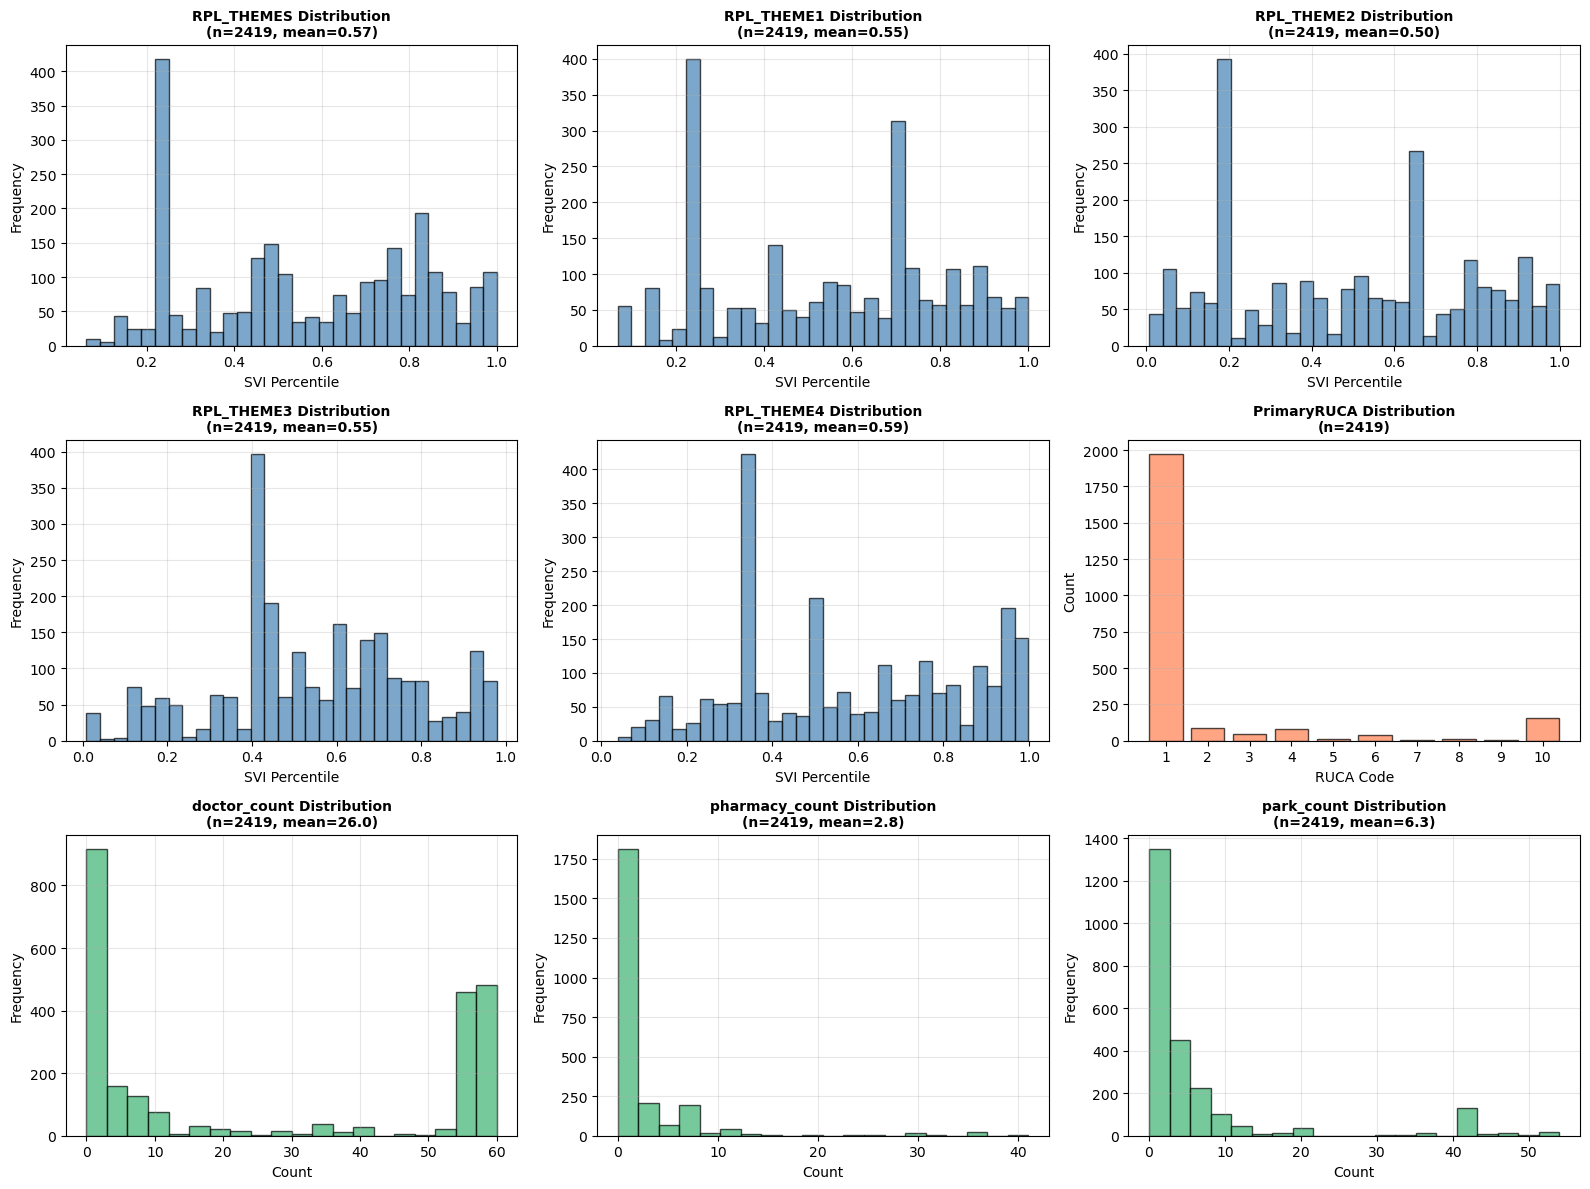


Saved geographic and SVI distributions summary visualization

CLUSTER DISTRIBUTION: PARTICIPANTS PER CLUSTER

Total unique clusters: 10
Total participants: 2863
Mean participants per cluster: 241.90
Median participants per cluster: 31
Max participants in a cluster: 1734
Min participants in a cluster: 2


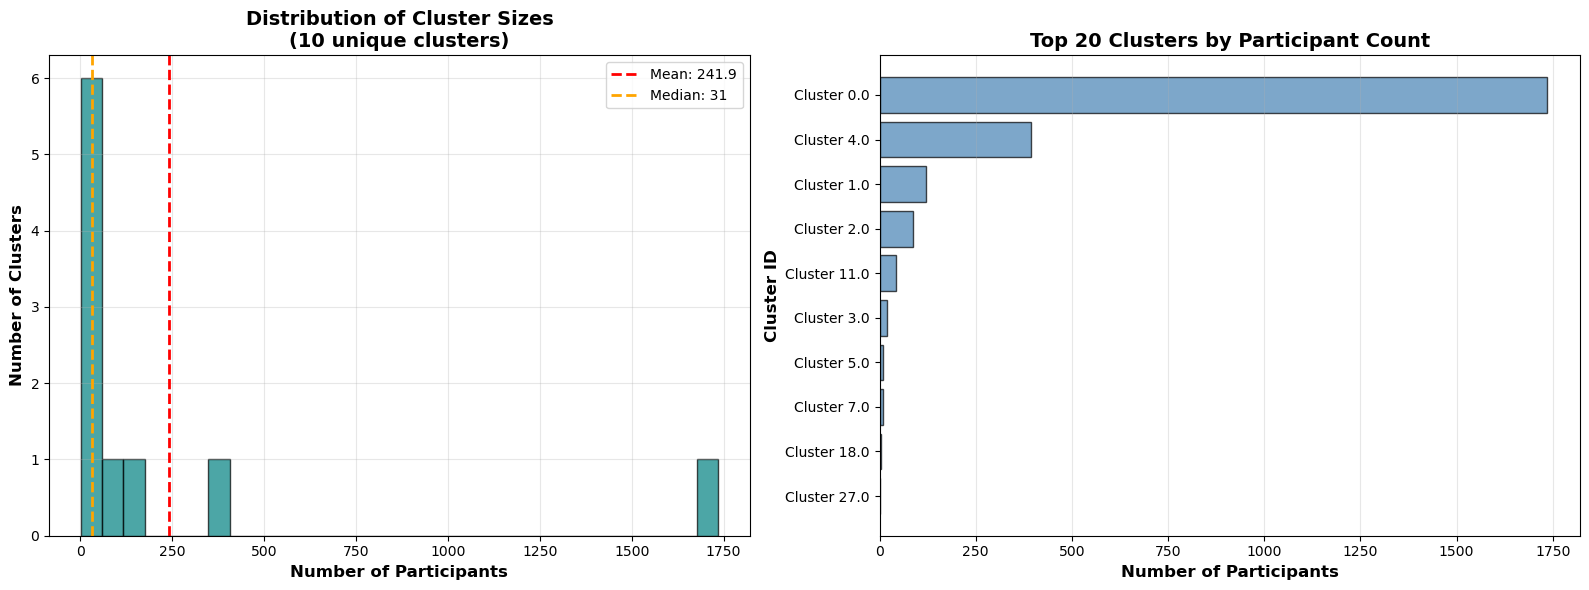


Saved cluster distribution visualization

Top 10 clusters with most participants:
  Cluster 0.0: 1734 participants
  Cluster 4.0: 395 participants
  Cluster 1.0: 120 participants
  Cluster 2.0: 86 participants
  Cluster 11.0: 42 participants
  Cluster 3.0: 20 participants
  Cluster 5.0: 8 participants
  Cluster 7.0: 8 participants
  Cluster 18.0: 4 participants
  Cluster 27.0: 2 participants

GEOGRAPHIC AND SVI SUMMARY STATISTICS
                    count       mean        std     min     25%      50%      75%      max
RPL_THEMES         2419.0   0.567514   0.259132  0.0626  0.3188   0.5687   0.8129   0.9998
RPL_THEME1         2419.0   0.552779   0.255818  0.0665  0.2641   0.5762   0.7329   0.9998
RPL_THEME2         2419.0   0.497889   0.292325  0.0069  0.1918   0.5227   0.7503   0.9995
RPL_THEME3         2419.0   0.549794   0.225432  0.0086  0.4255   0.5290   0.7121   0.9786
RPL_THEME4         2419.0   0.585411   0.258307  0.0387  0.3496   0.5608   0.8186   0.9979
doctor_count       

,Variable_Decoded,Variable,Count,Null_Count,Percent_Non-Null
0,Participant ID,pid,2863,0,100.00
17,Signal-to-Noise Ratio (SNR),snr,2863,0,100.00
18,Predicted MOS,pred_mos,2863,0,100.00
19,Pause Proportion,pause_proportion,2863,0,100.00
20,PHQ-9 Total,phq9-total,2863,0,100.00
21,HPSVQ Total,hpsvq-total-score,2863,0,100.00
15,Log Word Error Rate,log_wer,2863,0,100.00
16,Sentence Coherence (SentBERT),sentCoherenceSentBertCumulativeCentroid,2863,0,100.00
14,Word Error Rate (WER),wer,2863,0,100.00
22,SCL Global Score,scl-avg-global-score,2863,0,100.00


In [ ]:
# Clean merged dataframe with location data
if 'merged_df' in locals():
    print("Original merged_df shape:", merged_df.shape)
    
    # Identify duplicate columns (columns that existed in X_basic_plus_clin_sdh)
    original_cols = set(X_basic_plus_clin_sdh.columns)
    location_cols = set(merged_df.columns) - original_cols
    duplicate_cols = location_cols.intersection(original_cols)
    
    print(f"\nDuplicate columns to drop: {len(duplicate_cols)}")
    if len(duplicate_cols) > 0:
        print(f"Examples: {list(duplicate_cols)[:10]}")
    
    # Also drop account_id (duplicate of pid)
    cols_to_drop = list(duplicate_cols) + ['account_id']
    cols_to_drop = [col for col in cols_to_drop if col in merged_df.columns]
    
    # Drop duplicate columns
    X_location_clean = merged_df.drop(columns=cols_to_drop, errors='ignore')
    print(f"\nAfter dropping duplicates: {X_location_clean.shape}")
    
    # Remove columns with 0 or 1 unique values (causes R regression errors)
    single_value_cols = [col for col in X_location_clean.columns if X_location_clean[col].nunique() <= 1]
    if len(single_value_cols) > 0:
        print(f"\nRemoving {len(single_value_cols)} columns with 0 or 1 unique values:")
        print(f"  {single_value_cols}")
        X_location_clean = X_location_clean.drop(columns=single_value_cols)
        print(f"After removing constant columns: {X_location_clean.shape}")
    
    # Identify categorical location columns to encode
    categorical_location_cols = []
    
    # Check which categorical columns exist
    potential_categorical = ['PrimaryRUCA', 'SecondaryRUCA', 'STATEFP']
    for col in potential_categorical:
        if col in X_location_clean.columns:
            categorical_location_cols.append(col)
            print(f"\n{col} unique values: {X_location_clean[col].nunique()}")
    
    # One-hot encode categorical location variables
    if len(categorical_location_cols) > 0:
        print(f"\nOne-hot encoding: {categorical_location_cols}")
        X_location_encoded = one_hot_encode(df=X_location_clean, cols2encode=categorical_location_cols)
        
        # Drop original categorical columns and add encoded versions
        X_location_final = X_location_clean.drop(columns=categorical_location_cols)
        X_location_final = pd.concat([X_location_final, X_location_encoded], axis=1)
        
        print(f"\nFinal shape after encoding: {X_location_final.shape}")
    else:
        print("\nNo categorical location columns found to encode")
        X_location_final = X_location_clean
    
    # Save final dataset
    X_location_final.to_csv(out_folder + "X_basic_plus_clin_sdh_location_encoded.csv")
    print("\nSaved X_basic_plus_clin_sdh_location_encoded.csv")
    

    # Display column summary
    print(f"\nFinal dataset columns: {X_location_final.shape[1]}")
    location_specific_cols = [col for col in X_location_final.columns if col not in X_basic_plus_clin_sdh.columns]
    print(f"Location-specific columns added: {len(location_specific_cols)}")
    print(f"Examples: {location_specific_cols[:20]}")
    
    # Create graphic summary of geographic and SVI distributions
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("\n" + "="*80)
    print("GEOGRAPHIC AND SVI DISTRIBUTION SUMMARY")
    print("="*80)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. SVI THEMES DISTRIBUTIONS (histograms)
    svi_cols = ['RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']
    available_svi = [col for col in svi_cols if col in X_location_final.columns]
    
    if available_svi:
        for idx, col in enumerate(available_svi, 1):
            ax = plt.subplot(3, 3, idx)
            data = X_location_final[col].dropna()
            ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.2f})', fontsize=10, fontweight='bold')
            ax.set_xlabel('SVI Percentile')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
    
    # 2. RUCA DISTRIBUTIONS (if available before encoding)
    # Note: These are one-hot encoded in X_location_final, so show summary
    ruca_cols = ['PrimaryRUCA', 'SecondaryRUCA']
    for col in ruca_cols:
        if col in merged_df.columns:  # Check in original merged_df before encoding
            ax = plt.subplot(3, 3, len(available_svi) + ruca_cols.index(col) + 1)
            ruca_data = merged_df[col].dropna().value_counts().sort_index()
            ax.bar(range(len(ruca_data)), ruca_data.values, color='coral', alpha=0.7, edgecolor='black')
            ax.set_xticks(range(len(ruca_data)))
            ax.set_xticklabels(ruca_data.index.astype(int))
            ax.set_title(f'{col} Distribution\n(n={ruca_data.sum()})', fontsize=10, fontweight='bold')
            ax.set_xlabel('RUCA Code')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3, axis='y')
    
    # 3. POI COUNTS DISTRIBUTIONS
    poi_cols = ['doctor_count', 'pharmacy_count', 'hospital_count', 'park_count', 'bus_station_count', 'supermarket_count']
    available_poi = [col for col in poi_cols if col in X_location_final.columns]
    
    for idx, col in enumerate(available_poi[:3]):  # Show first 3
        ax = plt.subplot(3, 3, len(available_svi) + 2 + idx)
        data = X_location_final[col].dropna()
        ax.hist(data, bins=20, color='mediumseagreen', alpha=0.7, edgecolor='black')
        ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.1f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Count')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    
    # 4. REMAINING POI COUNTS (if space)
    for idx, col in enumerate(available_poi[3:]):
        if len(available_svi) + 2 + 3 + idx < 10:
            ax = plt.subplot(3, 3, len(available_svi) + 2 + 3 + idx)
            data = X_location_final[col].dropna()
            ax.hist(data, bins=20, color='mediumpurple', alpha=0.7, edgecolor='black')
            ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.1f})', fontsize=10, fontweight='bold')
            ax.set_xlabel('Count')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(out_folder + "geographic_svi_distributions_summary.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nSaved geographic and SVI distributions summary visualization")
    
    # Create cluster distribution visualization
    if 'cluster' in X_location_final.columns:
        print("\n" + "="*80)
        print("CLUSTER DISTRIBUTION: PARTICIPANTS PER CLUSTER")
        print("="*80)
        
        # Count participants per cluster
        cluster_counts = X_location_final['cluster'].value_counts().sort_index()
        
        print(f"\nTotal unique clusters: {len(cluster_counts)}")
        print(f"Total participants: {len(X_location_final)}")
        print(f"Mean participants per cluster: {cluster_counts.mean():.2f}")
        print(f"Median participants per cluster: {cluster_counts.median():.0f}")
        print(f"Max participants in a cluster: {cluster_counts.max()}")
        print(f"Min participants in a cluster: {cluster_counts.min()}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Histogram of participants per cluster
        ax1 = axes[0]
        ax1.hist(cluster_counts.values, bins=30, color='teal', alpha=0.7, edgecolor='black')
        ax1.set_xlabel('Number of Participants', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Number of Clusters', fontsize=12, fontweight='bold')
        ax1.set_title(f'Distribution of Cluster Sizes\n({len(cluster_counts)} unique clusters)', 
                      fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.axvline(cluster_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cluster_counts.mean():.1f}')
        ax1.axvline(cluster_counts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {cluster_counts.median():.0f}')
        ax1.legend()
        
        # Top 20 clusters by participant count
        ax2 = axes[1]
        top_clusters = cluster_counts.nlargest(20)
        ax2.barh(range(len(top_clusters)), top_clusters.values, color='steelblue', alpha=0.7, edgecolor='black')
        ax2.set_yticks(range(len(top_clusters)))
        ax2.set_yticklabels([f'Cluster {c}' for c in top_clusters.index])
        ax2.set_xlabel('Number of Participants', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cluster ID', fontsize=12, fontweight='bold')
        ax2.set_title('Top 20 Clusters by Participant Count', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.invert_yaxis()
        
        plt.tight_layout()
        plt.savefig(out_folder + "cluster_distribution_summary.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nSaved cluster distribution visualization")
        
        # Show some cluster statistics
        print("\nTop 10 clusters with most participants:")
        top_10 = cluster_counts.nlargest(10)
        for cluster_id, count in top_10.items():
            print(f"  Cluster {cluster_id}: {count} participants")
    
    # Summary statistics for geographic/SVI variables
    print("\n" + "="*80)
    print("GEOGRAPHIC AND SVI SUMMARY STATISTICS")
    print("="*80)
    
    summary_vars = available_svi + available_poi
    if summary_vars:
        summary_df = X_location_final[summary_vars].describe().T
        print(summary_df.to_string())
        
        # Show missing data
        print("\nMissing Data:")
        missing_geo = X_location_final[summary_vars].isna().sum()
        print(missing_geo[missing_geo > 0].to_string() if (missing_geo > 0).any() else "No missing data")

    # Change the count per participant calculation for cluster, to be count per diary, and count of participants per cluster
    # ToDo: check if PID is participant or diary

    # Create observation counts dataframe
    print("\n" + "="*80)
    print("OBSERVATION COUNTS FOR EACH VARIABLE")
    print("="*80)
    
    # Function to count observations correctly based on variable type
    def get_observation_count(series):
        """
        For boolean/binary variables (0/1), count the number of 1s.
        For other variables, count non-null values.
        """
        unique_vals = series.dropna().unique()
        # Check if it's a boolean/binary variable (only contains 0 and 1)
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            return (series == 1).sum()
        else:
            return series.notna().sum()
    
    # Calculate counts for each variable
    non_null_counts = []
    for col in X_location_final.columns:
        non_null_counts.append(get_observation_count(X_location_final[col]))
    
    variable_counts = pd.DataFrame({
        'Variable': X_location_final.columns,
        'Count': non_null_counts,
        'Null_Count': X_location_final.isna().sum().values,
        'Total_Rows': len(X_location_final),
        'Percent_Non-Null': (np.array(non_null_counts) / len(X_location_final) * 100).round(2)
    })
    
    # Add decoded variable names for better readability
    # Use a safe wrapper to handle any decoding errors
    def safe_decode(var_name):
        try:
            return decode_variable_name(var_name)
        except Exception as e:
            # If decoding fails, return the original variable name
            return var_name
    
    variable_counts['Variable_Decoded'] = variable_counts['Variable'].apply(safe_decode)
    
    # Sort by non-null count descending
    variable_counts = variable_counts.sort_values('Count', ascending=False)
    
    print(f"\nVariable counts summary:")
    print(variable_counts[['Variable_Decoded', 'Variable', 'Count', 'Null_Count', 'Percent_Non-Null']].to_string(index=False))
    
    # Save counts to CSV
    variable_counts.to_csv(out_folder + "X_location_encoded_variable_counts.csv", index=False)
    print(f"\nSaved variable counts to X_location_encoded_variable_counts.csv")
    
    # Display the variable counts dataframe with decoded names
    display(variable_counts[['Variable_Decoded', 'Variable', 'Count', 'Null_Count', 'Percent_Non-Null']])
    
else:
    print("No merged_df found. Please run the previous cell first.")

### Create Stratification Variables
Create meaningful stratification variables for cluster-adjusted analyses:
- **Urban/Rural Categories**: From RUCA codes
- **SVI Vulnerability Levels**: Low/Medium/High based on RPL_THEMES percentiles
- **Healthcare Access**: Based on combined doctor/pharmacy/hospital counts

In [ ]:
# Create stratification variables by combining RUCA, REPL, SVI, Healthcare & Resource Access, and Cluster variables into meaningful categories for stratified analyses in R. This will allow us to analyze WER and coherence across different geographic and social vulnerability contexts.
import re


if 'X_location_final' in locals():
    print("="*80)
    print("CREATING STRATIFICATION VARIABLES")
    print("="*80)
    
    X_stratified = X_location_final.copy()
    
    # 1. URBAN/RURAL STRATIFICATION FROM RUCA CODES
    # RUCA codes: 1-3 = Urban, 4-6 = Suburban, 7-10 = Rural
    # ToDo: Erin got these RUCA bins from a Google suggestion on what's been used before
    # https://doh.wa.gov/sites/default/files/legacy/Documents/1500/RUCAGuide.pdf
    # From Patrick's data does secondary RUCA codes, 
    # Level Secondary RUCA Codes 
    # Urban core 
    # [1.0, 1.1] 
    # Suburban 
    # [ 2.0, 2.1, 3.0] 
    # Large rural 
    # [4.0, 4.1, 4.2, 5.0, 5.1, 5.2, 6.0, 6.1] 
    # Small town/rural 
    # [7.0, 7.1, 7.2, 7.3, 7.4, 8.0, 8.1, 8.2, 8.3, 8.4, 9.0, 9.1, 9.2,10.0, 
    # 10.1, 10.2, 10.3, 10.4, 10.5, 10.6] 
    print("\n1. Urban/Rural Classification from RUCA Codes")
    print("-" * 80)
    
    if 'PrimaryRUCA' in merged_df.columns:

        
        def classify_urban_rural(ruca_code):
            """Classify RUCA code into urban/suburban/rural categories."""
            if pd.isna(ruca_code):
                return 'Unknown'
            s = str(ruca_code).strip()
            # grab first numeric portion (integer or float, optionally negative)
            m = re.search(r'(-?\d+(?:\.\d+)?)', s)
            if not m:
                return 'Unknown'
            try:
                val = float(m.group(1))
            except ValueError:
                return 'Unknown'
        
            if val <= 1:
                return 'UrbanCore'
            elif val <= 3:
                return 'Suburban'
            elif val <= 6:
                return 'LargeRural'
            elif val <= 10:
                return 'SmallTownRural'
            else:
                return 'Rural'

        X_stratified['urban_rural_category'] = merged_df['PrimaryRUCA'].apply(classify_urban_rural)
        # create the categorical column

        # one‑hot encode it and join back to X_stratified
        dummies = pd.get_dummies(X_stratified['urban_rural_category'],
                                 prefix='urban_rural',
                                 dummy_na=False)   # drop NaN column if you don’t want one
        
        # either overwrite X_stratified or create a new dataframe
        X_stratified = pd.concat([X_stratified, dummies], axis=1)
        print(f"Created urban/rural categories and one-hot encoded them. New shape: {X_stratified.shape}")
        print(X_stratified.head())

        # optionally drop the original column if you only want the encoded features
        #X_stratified.drop(columns='urban_rural_category', inplace=True)

        # Also create binary urban vs non-urban
        X_stratified['is_urban'] = (merged_df['PrimaryRUCA'] <= 3).astype(float)
        
        print("Distribution of Urban/Rural Categories:")
        print(X_stratified['urban_rural_category'].value_counts())
        print(f"\nUrban participants: {X_stratified['is_urban'].sum():.0f} ({X_stratified['is_urban'].mean()*100:.1f}%)")
    else:
        print("WARNING: PrimaryRUCA not found in merged_df, skipping urban/rural classification")

    
    # 2. SVI VULNERABILITY STRATIFICATION
    # RPL_THEMES: 0-0.33 = Low vulnerability, 0.33-0.66 = Medium, 0.66-1.0 = High
    # ToDo: Base theses off SVI research literature, want to make sure informed categorizations
    # https://hqin.org/wp-content/uploads/2022/09/Social-Vulnerability-Index-Toolkit.pdf
    print("\n2. SVI Vulnerability Levels")
    print("-" * 80)
    
    if 'RPL_THEMES' in X_location_final.columns:
        def classify_svi_level(svi_score):
            """Classify SVI score into low/medium/high vulnerability"""
            if pd.isna(svi_score):
                return 'Unknown'
            elif svi_score < 0.33:
                return 'Low Vulnerability'
            elif svi_score < 0.66:
                return 'Medium Vulnerability'
            else:
                return 'High Vulnerability'
        
        X_stratified['svi_category'] = X_location_final['RPL_THEMES'].apply(classify_svi_level)
        
        # Also create binary high vulnerability indicator
        X_stratified['high_svi'] = (X_location_final['RPL_THEMES'] >= 0.66).astype(float)
        
        print("Distribution of SVI Categories:")
        print(X_stratified['svi_category'].value_counts())
        print(f"\nHigh vulnerability areas: {X_stratified['high_svi'].sum():.0f} ({X_stratified['high_svi'].mean()*100:.1f}%)")
        
        # Also create SVI theme-specific categorizations
        svi_themes = ['RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']
        available_themes = [theme for theme in svi_themes if theme in X_location_final.columns]
        
        for theme in available_themes:
            theme_name = theme.replace('RPL_THEME', 'svi_theme')
            X_stratified[f'{theme_name}_high'] = (X_location_final[theme] >= 0.66).astype(float)
    else:
        print("WARNING: RPL_THEMES not found, skipping SVI classification")
    
    # 3. HEALTHCARE ACCESS STRATIFICATION
    # Combine doctor, pharmacy, and hospital counts
    # ToDo: Don't combine these for now. Run analyses separately with just counts. There are issues with combining counts of different types of POIs
    # Could turn into which quartile of access each participant is in for each POI type instead
    # Could also turn into PCA - Principal Component Analysis - to create composite access score. Summarize multiple access indicators
    print("\n3. Healthcare Access Levels")
    print("-" * 80)
    
    healthcare_cols = ['doctor_count', 'pharmacy_count', 'hospital_count']
    available_healthcare = [col for col in healthcare_cols if col in X_location_final.columns]
    
    if available_healthcare:
        # Create composite healthcare access score
        X_stratified['healthcare_access_score'] = X_location_final[available_healthcare].sum(axis=1)
        
        # Categorize into tertiles: Low/Medium/High access
        healthcare_tertiles = X_stratified['healthcare_access_score'].quantile([0.33, 0.66])
        
        def classify_healthcare_access(score):
            """Classify healthcare access score into tertiles"""
            if pd.isna(score):
                return 'Unknown'
            elif score <= healthcare_tertiles.iloc[0]:
                return 'Low Healthcare Access'
            elif score <= healthcare_tertiles.iloc[1]:
                return 'Medium Healthcare Access'
            else:
                return 'High Healthcare Access'
        
        X_stratified['healthcare_access_category'] = X_stratified['healthcare_access_score'].apply(classify_healthcare_access)
        
        # Also create binary low access indicator
        X_stratified['low_healthcare_access'] = (X_stratified['healthcare_access_score'] <= healthcare_tertiles.iloc[0]).astype(float)
        
        print(f"Healthcare tertile thresholds: Low<={healthcare_tertiles.iloc[0]:.1f}, Medium<={healthcare_tertiles.iloc[1]:.1f}")
        print("\nDistribution of Healthcare Access Categories:")
        print(X_stratified['healthcare_access_category'].value_counts())
        print(f"\nLow healthcare access: {X_stratified['low_healthcare_access'].sum():.0f} ({X_stratified['low_healthcare_access'].mean()*100:.1f}%)")
    else:
        print("WARNING: No healthcare count variables found, skipping healthcare access classification")
    
    # 4. RESOURCE ACCESS STRATIFICATION
    # Combine supermarket, park, bus station counts
    # ToDo: just do these with counts? Don't combine just yet
    print("\n4. Community Resource Access Levels")
    print("-" * 80)
    
    resource_cols = ['supermarket_count', 'park_count', 'bus_station_count']
    available_resources = [col for col in resource_cols if col in X_location_final.columns]
    
    if available_resources:
        # Create composite resource access score
        X_stratified['resource_access_score'] = X_location_final[available_resources].sum(axis=1)
        
        # Categorize into tertiles
        resource_tertiles = X_stratified['resource_access_score'].quantile([0.33, 0.66])
        
        def classify_resource_access(score):
            """Classify resource access score into tertiles"""
            if pd.isna(score):
                return 'Unknown'
            elif score <= resource_tertiles.iloc[0]:
                return 'Low Resource Access'
            elif score <= resource_tertiles.iloc[1]:
                return 'Medium Resource Access'
            else:
                return 'High Resource Access'
        
        X_stratified['resource_access_category'] = X_stratified['resource_access_score'].apply(classify_resource_access)
        
        # Also create binary low access indicator
        X_stratified['low_resource_access'] = (X_stratified['resource_access_score'] <= resource_tertiles.iloc[0]).astype(float)
        
        print(f"Resource tertile thresholds: Low<={resource_tertiles.iloc[0]:.1f}, Medium<={resource_tertiles.iloc[1]:.1f}")
        print("\nDistribution of Resource Access Categories:")
        print(X_stratified['resource_access_category'].value_counts())
        print(f"\nLow resource access: {X_stratified['low_resource_access'].sum():.0f} ({X_stratified['low_resource_access'].mean()*100:.1f}%)")
    else:
        print("WARNING: No resource count variables found, skipping resource access classification")
    
    # 5. COMBINED STRATIFICATIONS
    # Create useful combinations for interaction analyses
    print("\n5. Combined Stratification Variables")
    print("-" * 80)
    
    if 'urban_rural_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
        X_stratified['urban_high_svi'] = ((X_stratified['urban_rural_category'] == 'Urban') & 
                                           (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        X_stratified['rural_high_svi'] = ((X_stratified['urban_rural_category'] == 'Rural') & 
                                           (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        
        print(f"Urban + High SVI: {X_stratified['urban_high_svi'].sum():.0f} participants")
        print(f"Rural + High SVI: {X_stratified['rural_high_svi'].sum():.0f} participants")
    
    if 'healthcare_access_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
        X_stratified['low_healthcare_high_svi'] = ((X_stratified['healthcare_access_category'] == 'Low Healthcare Access') & 
                                                    (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        
        print(f"Low Healthcare + High SVI: {X_stratified['low_healthcare_high_svi'].sum():.0f} participants")


    # Remove columns
    X_stratified = X_stratified.drop(columns=['svi_category', 'park_count', 'high_svi', 
                                              'bus_station_count', 'supermarket_count', 'doctor_count', 'pharmacy_count', 'park_count',
                                              'cluster', 
                                              'is_urban', 
                                              # 'urban_rural_category'
                                              #ToDo: question about why dropping SNR?
                                              'snr',
                                              'PrimaryRUCA_10.0', 'PrimaryRUCA_1.0', 'PrimaryRUCA_2.0', 'PrimaryRUCA_3.0', 'PrimaryRUCA_4.0',
                                              'PrimaryRUCA_5.0', 'PrimaryRUCA_6.0', 'PrimaryRUCA_7.0', 'PrimaryRUCA_8.0',
                                              'PrimaryRUCA_9.0', 'PrimaryRUCA_nan',
                                              'urban_high_svi', 'rural_high_svi', 'low_healthcare_high_svi',
                                              'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES'], errors='ignore')

    # TODO: One-hot encode the new stratification categories, only did urban_rural_category above
    #stratification_cols = ['urban_rural_category', 'healthcare_access_category', 'resource_access_category']

    # SAVE STRATIFIED DATASET
    print("\n" + "="*80)
    print("SAVING STRATIFIED DATASET")
    print("="*80)

    X_stratified.to_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv")
    print(f"\nSaved stratified dataset: {X_stratified.shape}")
    print(f"New stratification columns added: {len(X_stratified.columns) - len(X_location_final.columns)}")
    

CREATING STRATIFICATION VARIABLES

1. Urban/Rural Classification from RUCA Codes
--------------------------------------------------------------------------------
Created urban/rural categories and one-hot encoded them. New shape: (2863, 60)
    pid  race_2.0  race_4.0  race_5.0  race_6.0  race_999.0  gender_2.0  \
0  1870       0.0       0.0       0.0       0.0         0.0         1.0   
1  1870       0.0       0.0       0.0       0.0         0.0         1.0   
2  1553       0.0       0.0       0.0       1.0         0.0         1.0   
3  1788       0.0       0.0       0.0       1.0         0.0         1.0   
4  2319       0.0       0.0       0.0       0.0         0.0         0.0   

   gender_3.0  gender_4.0  gender_5.0  ...  PrimaryRUCA_8.0  PrimaryRUCA_9.0  \
0         0.0         0.0         0.0  ...              0.0              0.0   
1         0.0         0.0         0.0  ...              0.0              0.0   
2         0.0         0.0         0.0  ...              0.0         

In [ ]:

#     # Display summary of all stratification variables
#     stratification_vars = [col for col in X_stratified.columns if col not in X_location_final.columns]
#     print(f"\nStratification variables created ({len(stratification_vars)}):")
#     for var in stratification_vars:
#         print(f"  - {var}")
    
#     # VISUALIZATION: Stratification distributions
#     import matplotlib.pyplot as plt
#     import seaborn as sns
    
#     print("\n" + "="*80)
#     print("STRATIFICATION DISTRIBUTION VISUALIZATIONS")
#     print("="*80)
    
#     # Create figure with stratification distributions
#     fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
#     # Plot 1: Urban/Rural distribution
#     if 'urban_rural_category' in X_stratified.columns:
#         ax = axes[0, 0]
#         category_counts = X_stratified['urban_rural_category'].value_counts()
#         ax.bar(range(len(category_counts)), category_counts.values, color='teal', alpha=0.7, edgecolor='black')
#         ax.set_xticks(range(len(category_counts)))
#         ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
#         ax.set_title('Urban/Rural Distribution', fontsize=12, fontweight='bold')
#         ax.set_ylabel('Number of Participants')
#         ax.grid(True, alpha=0.3, axis='y')
    
#     # Plot 2: SVI category distribution
#     if 'svi_category' in X_stratified.columns:
#         ax = axes[0, 1]
#         category_counts = X_stratified['svi_category'].value_counts()
#         ax.bar(range(len(category_counts)), category_counts.values, color='coral', alpha=0.7, edgecolor='black')
#         ax.set_xticks(range(len(category_counts)))
#         ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
#         ax.set_title('SVI Vulnerability Levels', fontsize=12, fontweight='bold')
#         ax.set_ylabel('Number of Participants')
#         ax.grid(True, alpha=0.3, axis='y')
    
#     # Plot 3: Healthcare access distribution
#     if 'healthcare_access_category' in X_stratified.columns:
#         ax = axes[0, 2]
#         category_counts = X_stratified['healthcare_access_category'].value_counts()
#         ax.bar(range(len(category_counts)), category_counts.values, color='mediumseagreen', alpha=0.7, edgecolor='black')
#         ax.set_xticks(range(len(category_counts)))
#         ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
#         ax.set_title('Healthcare Access Levels', fontsize=12, fontweight='bold')
#         ax.set_ylabel('Number of Participants')
#         ax.grid(True, alpha=0.3, axis='y')
    
#     # Plot 4: Resource access distribution
#     if 'resource_access_category' in X_stratified.columns:
#         ax = axes[1, 0]
#         category_counts = X_stratified['resource_access_category'].value_counts()
#         ax.bar(range(len(category_counts)), category_counts.values, color='mediumpurple', alpha=0.7, edgecolor='black')
#         ax.set_xticks(range(len(category_counts)))
#         ax.set_xticklabels(category_counts.index, rotation=45, ha='right')
#         ax.set_title('Community Resource Access', fontsize=12, fontweight='bold')
#         ax.set_ylabel('Number of Participants')
#         ax.grid(True, alpha=0.3, axis='y')
    
#     # Plot 5: Healthcare access score histogram
#     if 'healthcare_access_score' in X_stratified.columns:
#         ax = axes[1, 1]
#         data = X_stratified['healthcare_access_score'].dropna()
#         ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
#         ax.axvline(healthcare_tertiles.iloc[0], color='red', linestyle='--', linewidth=2, label='33rd percentile')
#         ax.axvline(healthcare_tertiles.iloc[1], color='orange', linestyle='--', linewidth=2, label='66th percentile')
#         ax.set_title('Healthcare Access Score Distribution', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Healthcare Access Score')
#         ax.set_ylabel('Frequency')
#         ax.legend()
#         ax.grid(True, alpha=0.3)
    
#     # Plot 6: Resource access score histogram
#     if 'resource_access_score' in X_stratified.columns:
#         ax = axes[1, 2]
#         data = X_stratified['resource_access_score'].dropna()
#         ax.hist(data, bins=30, color='darkseagreen', alpha=0.7, edgecolor='black')
#         ax.axvline(resource_tertiles.iloc[0], color='red', linestyle='--', linewidth=2, label='33rd percentile')
#         ax.axvline(resource_tertiles.iloc[1], color='orange', linestyle='--', linewidth=2, label='66th percentile')
#         ax.set_title('Resource Access Score Distribution', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Resource Access Score')
#         ax.set_ylabel('Frequency')
#         ax.legend()
#         ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(out_folder + "stratification_distributions.png", dpi=300, bbox_inches='tight')
#     plt.show()
    
#     print("\nSaved stratification distribution visualizations")
    
#     # CROSS-TABULATION OF KEY STRATIFICATIONS
#     print("\n" + "="*80)
#     print("CROSS-TABULATIONS OF STRATIFICATION VARIABLES")
#     print("="*80)
    
#     if 'urban_rural_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
#         print("\nUrban/Rural × SVI Vulnerability:")
#         cross_tab = pd.crosstab(X_stratified['urban_rural_category'], X_stratified['svi_category'], margins=True)
#         print(cross_tab)
    
#     if 'urban_rural_category' in X_stratified.columns and 'healthcare_access_category' in X_stratified.columns:
#         print("\nUrban/Rural × Healthcare Access:")
#         cross_tab = pd.crosstab(X_stratified['urban_rural_category'], X_stratified['healthcare_access_category'], margins=True)
#         print(cross_tab)
    
#     if 'svi_category' in X_stratified.columns and 'healthcare_access_category' in X_stratified.columns:
#         print("\nSVI Vulnerability × Healthcare Access:")
#         cross_tab = pd.crosstab(X_stratified['svi_category'], X_stratified['healthcare_access_category'], margins=True)
#         print(cross_tab)
    
#     print("\n" + "="*80)
#     print("STRATIFICATION VARIABLES CREATION COMPLETE")
#     print("="*80)
#     print("\nRecommended analysis approaches:")
#     print("1. Include stratification variables as fixed effects in mixed models")
#     print("2. Test interactions between stratification variables and predictors")
#     print("3. Conduct sensitivity analyses within each stratification group")
#     print("4. Always include cluster as a random effect to account for geographic clustering")
    
# else:
#     print("ERROR: X_location_final not found. Please run the previous cell first.")

In [ ]:
# Multiple Hypothesis Testing Correction + VIF + R-like clustered regressions
# For file: X_basic_plus_clin_sdh_location_stratified.csv

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from patsy.builtins import Q

# Load stratified data
X_stratified = pd.read_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv", index_col=0)

print("=" * 80)
print("MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. VIF ANALYSIS - keep numeric-only VIF diagnostics
# ============================================================================
print("\n1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("-" * 80)

numeric_cols = [col for col in X_stratified.select_dtypes(include=[np.number]).columns if col != "pid"]
X_for_vif = X_stratified[numeric_cols].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]

def interpret_vif(vif):
    if vif < 5:
        return "OK"
    return "Concerning" if vif < 10 else "SERIOUS"

vif_data["Assessment"] = vif_data["VIF"].apply(interpret_vif)
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string())
vif_data.to_csv(out_folder + "vif_stratified_analysis.csv", index=False)
print(f"\nVIF results saved to: {out_folder}vif_stratified_analysis.csv")

# ============================================================================
# 2. R-like regression with formula, categorical handling, clustered SE by pid
# ============================================================================
print("\n\n2. REGRESSION MODELS FOR BOTH OUTCOMES (R-LIKE SPECS + CLUSTERED SE)")
print("-" * 80)

# Use outcomes from current design matrix to align with R's formula data= location_stratified_df
outcomes = ["log_wer", "sentCoherenceSentBertCumulativeCentroid"]

results_list = []
for outcome_name in outcomes:
    if outcome_name == "log_wer":
        exclude = {"log_wer", "sentCoherenceSentBertCumulativeCentroid", "wer"}
    else:
        exclude = {"sentCoherenceSentBertCumulativeCentroid", "log_wer", "wer"}

    predictors = [c for c in X_stratified.columns if c not in exclude]

    # Build R-like formula terms, handling special chars and categoricals
    terms = []
    for c in predictors:
        qc = f'Q("{c}")'
        if pd.api.types.is_object_dtype(X_stratified[c]) or isinstance(X_stratified[c].dtype, pd.CategoricalDtype):
            terms.append(f"C({qc})")
        else:
            terms.append(qc)

    formula = f'Q("{outcome_name}") ~ ' + ' + '.join(terms)

    print(f"\n\nOUTCOME: {outcome_name}")
    print("=" * 80)
    print("Formula:")
    print(formula[:400] + ("..." if len(formula) > 400 else ""))

    # Match R inference: clustered robust SE by pid
    model = smf.ols(formula=formula, data=X_stratified).fit(
        cov_type="cluster",
        cov_kwds={"groups": X_stratified["pid"], "use_correction": True}
    )

    coef_table = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Std_Error": model.bse.values,
        "t_statistic": model.tvalues.values,
        "p_value": model.pvalues.values
    })

    # Multiple-testing correction excluding intercept
    const_mask = coef_table["Variable"].isin(["Intercept", "const"])
    coef_table_for_correction = coef_table.loc[~const_mask].copy()

    reject_bonf, p_bonf, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="bonferroni")
    reject_fdr, p_fdr, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="fdr_bh")

    coef_table_for_correction["p_bonferroni"] = p_bonf
    coef_table_for_correction["bonferroni_significant"] = reject_bonf
    coef_table_for_correction["p_fdr"] = p_fdr
    coef_table_for_correction["fdr_significant"] = reject_fdr

    if const_mask.any():
        const_row = coef_table.loc[const_mask].copy()
        const_row["p_bonferroni"] = np.nan
        const_row["bonferroni_significant"] = False
        const_row["p_fdr"] = np.nan
        const_row["fdr_significant"] = False
        coef_table_out = pd.concat([const_row, coef_table_for_correction], ignore_index=True)
    else:
        coef_table_out = coef_table_for_correction.copy()

    filename = out_folder + f"regression_stratified_{outcome_name}.csv"
    coef_table_out.to_csv(filename, index=False)
    print(f"Regression results saved to: {filename}")

    print(f"Model R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print("Significant variables (FDR corrected, alpha=0.05):")
    sig_vars = coef_table_out[coef_table_out["fdr_significant"] == True]
    if len(sig_vars) > 0:
        print(sig_vars[["Variable", "Coefficient", "p_value", "p_fdr"]].to_string(index=False))
    else:
        print("   None")

    results_list.append(coef_table_out)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"All results saved to: {out_folder}")


In [ ]:
# Add a cell that compares the regression_stratified_log_wer.csv. "/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv"), and 
# the regression calculated in sandwich_script.r, "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv",
# to compare and see if we have the same columns,
# and same results for each variable and coefficient, standard error, and p-value. This will help us validate that our Python regression results are consistent with the R results, 
# and that the multiple testing correction is being applied correctly in both analyses. 
# We can also check if the same variables are significant in both analyses after correction.

# Cell 89: Compare Python vs R stratified WER regression outputs

import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.multitest import multipletests

# ---- Paths ----
py_path = "/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv"
r_path = "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv"

# ---- Load ----
py = pd.read_csv(py_path)
r = pd.read_csv(r_path)

# ---- Standardize schema ----
py = py.rename(columns={
    "Variable": "term_py",
    "Coefficient": "coef_py",
    "Std_Error": "se_py",
    "p_value": "p_py",
    "p_bonferroni": "p_bonf_py",
    "bonferroni_significant": "sig_bonf_py",
    "p_fdr": "p_fdr_py",
    "fdr_significant": "sig_fdr_py",
})

r = r.rename(columns={
    r.columns[0]: "term_r_raw",   # first unnamed column in R output
    "Estimate": "coef_r",
    "Std. Error": "se_r",
    "Pr(>|t|)": "p_r",
})

# ---- Normalize variable names so they can be matched ----
def normalize_term(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip().strip('"')
    if t in {"(Intercept)", "const"}:
        return "const"
    # R file uses dots in some names; Python file uses hyphens
    return t.replace(".", "-")

py["term_norm"] = py["term_py"].map(normalize_term)
r["term_norm"] = r["term_r_raw"].map(normalize_term)

# ---- Recompute multiple testing correction on R side (excluding intercept) ----
mask_r_tests = r["term_norm"].ne("const") & r["p_r"].notna()
r.loc[mask_r_tests, "p_bonf_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="bonferroni")[1]
r.loc[mask_r_tests, "p_fdr_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="fdr_bh")[1]
r["sig_bonf_r"] = r["p_bonf_r"] < 0.05
r["sig_fdr_r"] = r["p_fdr_r"] < 0.05

# ---- Merge and compare ----
cmp = py.merge(
    r[["term_norm", "term_r_raw", "coef_r", "se_r", "p_r", "p_bonf_r", "p_fdr_r", "sig_bonf_r", "sig_fdr_r"]],
    on="term_norm",
    how="outer",
)

cmp["in_python"] = cmp["term_py"].notna()
cmp["in_r"] = cmp["term_r_raw"].notna()
cmp["missing_in_one_file"] = ~(cmp["in_python"] & cmp["in_r"])

# Tolerances for "close"
tol_coef = 1e-6
tol_se = 1e-6
tol_p = 1e-6

def close_or_na(a, b, atol):
    return np.where(a.notna() & b.notna(), np.isclose(a, b, atol=atol, rtol=1e-4), pd.NA)

cmp["coef_close"] = close_or_na(cmp["coef_py"], cmp["coef_r"], tol_coef)
cmp["se_close"] = close_or_na(cmp["se_py"], cmp["se_r"], tol_se)
cmp["p_close"] = close_or_na(cmp["p_py"], cmp["p_r"], tol_p)
cmp["p_bonf_close"] = close_or_na(cmp["p_bonf_py"], cmp["p_bonf_r"], tol_p)
cmp["p_fdr_close"] = close_or_na(cmp["p_fdr_py"], cmp["p_fdr_r"], tol_p)

cmp["sig_bonf_match"] = np.where(
    cmp["sig_bonf_py"].notna() & cmp["sig_bonf_r"].notna(),
    cmp["sig_bonf_py"] == cmp["sig_bonf_r"],
    pd.NA
)
cmp["sig_fdr_match"] = np.where(
    cmp["sig_fdr_py"].notna() & cmp["sig_fdr_r"].notna(),
    cmp["sig_fdr_py"] == cmp["sig_fdr_r"],
    pd.NA
)

cmp["any_numeric_mismatch"] = (
    (cmp["coef_close"] == False)
    | (cmp["se_close"] == False)
    | (cmp["p_close"] == False)
    | (cmp["p_bonf_close"] == False)
    | (cmp["p_fdr_close"] == False)
)

cmp["any_sig_mismatch"] = (
    (cmp["sig_bonf_match"] == False)
    | (cmp["sig_fdr_match"] == False)
)

cmp["flag"] = np.select(
    [
        cmp["missing_in_one_file"],
        cmp["any_numeric_mismatch"],
        cmp["any_sig_mismatch"],
    ],
    [
        "missing_variable",
        "numeric_mismatch",
        "significance_mismatch",
    ],
    default="ok",
)

# ---- Output tables ----
comparison_table = cmp[[
    "term_norm", "term_py", "term_r_raw", "in_python", "in_r", "flag",
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close",
    "p_bonf_py", "p_bonf_r", "p_bonf_close", "sig_bonf_py", "sig_bonf_r", "sig_bonf_match",
    "p_fdr_py", "p_fdr_r", "p_fdr_close", "sig_fdr_py", "sig_fdr_r", "sig_fdr_match",
]].sort_values(["flag", "term_norm"])

flagged = comparison_table[comparison_table["flag"] != "ok"].copy()
summary = (
    comparison_table["flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="n_terms")
)

print("Summary of comparison:")
display(summary)

print("Flagged rows (missing vars or mismatches):")
display(flagged)

print("Full comparison table:")
display(comparison_table)

# Compact save cell
out_dir = "/edata/obdw/sandwich_analysis_data"
comparison_table.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_full.csv", index=False)
flagged.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv", index=False)
summary.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_summary.csv", index=False)

print("Saved:")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_full.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_summary.csv")



Summary of comparison:


,flag,n_terms
0,numeric_mismatch,35
1,missing_variable,11


Flagged rows (missing vars or mismatches):


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
14,healthcare_access_categoryLow Healthcare Access,NaN,healthcare_access_categoryLow Healthcare Access,False,True,missing_variable,NaN,1.359730e+00,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.409540,<NA>,NaN,False,<NA>
15,healthcare_access_categoryMedium Healthcare Ac...,NaN,healthcare_access_categoryMedium Healthcare Ac...,False,True,missing_variable,NaN,5.800041e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.847682,<NA>,NaN,False,<NA>
18,low_healthcare_access,low_healthcare_access,NaN,True,False,missing_variable,0.383436,NaN,<NA>,0.164229,...,<NA>,False,NaN,<NA>,1.009305e-01,NaN,<NA>,False,NaN,<NA>
19,low_resource_access,low_resource_access,NaN,True,False,missing_variable,-0.361518,NaN,<NA>,0.167085,...,<NA>,False,NaN,<NA>,1.375749e-01,NaN,<NA>,False,NaN,<NA>
23,pid,NaN,pid,False,True,missing_variable,NaN,3.117154e-07,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.997700,<NA>,NaN,False,<NA>
30,resource_access_categoryLow Resource Access,NaN,resource_access_categoryLow Resource Access,False,True,missing_variable,NaN,-4.191741e-02,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.995835,<NA>,NaN,False,<NA>
31,resource_access_categoryMedium Resource Access,NaN,resource_access_categoryMedium Resource Access,False,True,missing_variable,NaN,2.045071e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.847682,<NA>,NaN,False,<NA>
42,urban_rural_categorySmallTownRural,NaN,urban_rural_categorySmallTownRural,False,True,missing_variable,NaN,-8.132145e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.529248,<NA>,NaN,False,<NA>
43,urban_rural_categorySuburban,NaN,urban_rural_categorySuburban,False,True,missing_variable,NaN,-7.854864e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.409540,<NA>,NaN,False,<NA>
44,urban_rural_categoryUnknown,NaN,urban_rural_categoryUnknown,False,True,missing_variable,NaN,-8.449390e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.321891,<NA>,NaN,False,<NA>


Full comparison table:


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
14,healthcare_access_categoryLow Healthcare Access,NaN,healthcare_access_categoryLow Healthcare Access,False,True,missing_variable,NaN,1.359730e+00,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.409540,<NA>,NaN,False,<NA>
15,healthcare_access_categoryMedium Healthcare Ac...,NaN,healthcare_access_categoryMedium Healthcare Ac...,False,True,missing_variable,NaN,5.800041e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.847682,<NA>,NaN,False,<NA>
18,low_healthcare_access,low_healthcare_access,NaN,True,False,missing_variable,0.383436,NaN,<NA>,0.164229,...,<NA>,False,NaN,<NA>,1.009305e-01,NaN,<NA>,False,NaN,<NA>
19,low_resource_access,low_resource_access,NaN,True,False,missing_variable,-0.361518,NaN,<NA>,0.167085,...,<NA>,False,NaN,<NA>,1.375749e-01,NaN,<NA>,False,NaN,<NA>
23,pid,NaN,pid,False,True,missing_variable,NaN,3.117154e-07,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.997700,<NA>,NaN,False,<NA>
30,resource_access_categoryLow Resource Access,NaN,resource_access_categoryLow Resource Access,False,True,missing_variable,NaN,-4.191741e-02,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.995835,<NA>,NaN,False,<NA>
31,resource_access_categoryMedium Resource Access,NaN,resource_access_categoryMedium Resource Access,False,True,missing_variable,NaN,2.045071e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.847682,<NA>,NaN,False,<NA>
42,urban_rural_categorySmallTownRural,NaN,urban_rural_categorySmallTownRural,False,True,missing_variable,NaN,-8.132145e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.529248,<NA>,NaN,False,<NA>
43,urban_rural_categorySuburban,NaN,urban_rural_categorySuburban,False,True,missing_variable,NaN,-7.854864e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.409540,<NA>,NaN,False,<NA>
44,urban_rural_categoryUnknown,NaN,urban_rural_categoryUnknown,False,True,missing_variable,NaN,-8.449390e-01,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.321891,<NA>,NaN,False,<NA>


Saved:
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_full.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_flagged.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv


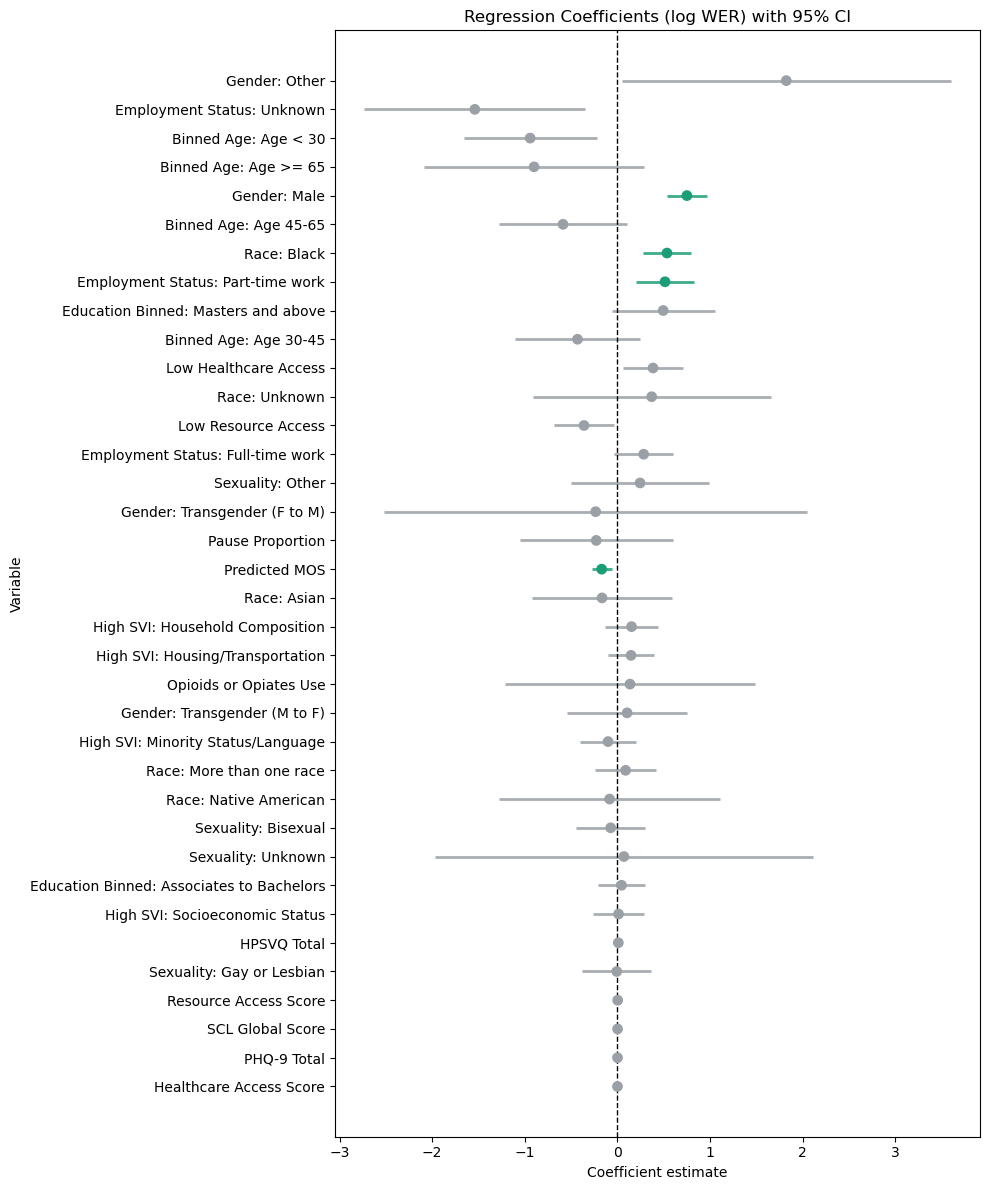

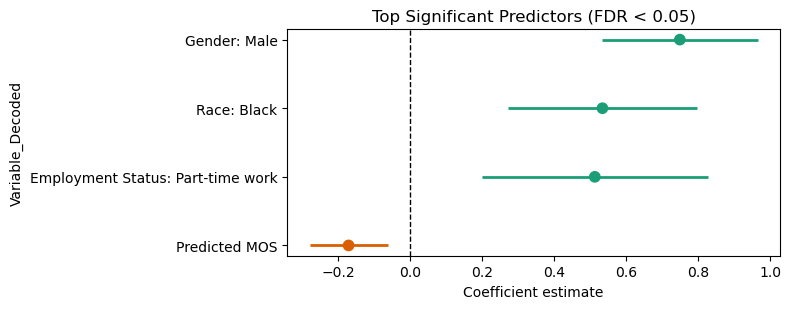

In [ ]:
# Add Graph of Multi-Hypothesis corrected results
# Made this cell using Codex
# Top significant predictors only (FDR-significant), sorted by absolute effect size
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
df = pd.read_csv("/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv")

# Clean/prepare
for col in ["fdr_significant", "bonferroni_significant"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})
df["ci_low"] = df["Coefficient"] - 1.96 * df["Std_Error"]
df["ci_high"] = df["Coefficient"] + 1.96 * df["Std_Error"]

# Optional: drop intercept for readability
plot_df = df[df["Variable"] != "const"].copy()
# Add variable decodes
plot_df['Variable_Decoded'] = plot_df['Variable'].apply(safe_decode)
# Build decoded labels (fallback to original if decode fails/empty)
plot_df["Variable_Decoded"] = (
    plot_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(plot_df["Variable"])
)
plot_df["Variable_Decoded"] = np.where(
    plot_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    plot_df["Variable"],
    plot_df["Variable_Decoded"]
)


# Sort by effect size magnitude
plot_df = plot_df.reindex(plot_df["Coefficient"].abs().sort_values(ascending=True).index)

# Plot: coefficient forest plot with 95% CI
plt.figure(figsize=(10, 12))
colors = np.where(plot_df["fdr_significant"], "#1b9e77", "#9aa0a6")

plt.hlines(
    y=plot_df["Variable_Decoded"],
    xmin=plot_df["ci_low"],
    xmax=plot_df["ci_high"],
    color=colors,
    alpha=0.85,
    linewidth=2
)
plt.scatter(
    plot_df["Coefficient"],
    plot_df["Variable_Decoded"],
    c=colors,
    s=45,
    zorder=3
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Regression Coefficients (log WER) with 95% CI")
plt.xlabel("Coefficient estimate")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


sig_df = df[(df["Variable"] != "const") & (df["fdr_significant"] == True)].copy()
# Build decoded labels (fallback to original if decode fails/empty)
sig_df["Variable_Decoded"] = (
    sig_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(sig_df["Variable"])
)
sig_df["Variable_Decoded"] = np.where(
    sig_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    sig_df["Variable"],
    sig_df["Variable_Decoded"]
)
if sig_df.empty:
    print("No FDR-significant predictors found.")
else:
    sig_df["ci_low"] = sig_df["Coefficient"] - 1.96 * sig_df["Std_Error"]
    sig_df["ci_high"] = sig_df["Coefficient"] + 1.96 * sig_df["Std_Error"]
    sig_df = sig_df.reindex(sig_df["Coefficient"].abs().sort_values(ascending=True).index)

    plt.figure(figsize=(8, max(3, 0.8 * len(sig_df))))
    colors = np.where(sig_df["Coefficient"] >= 0, "#1b9e77", "#d95f02")

    plt.hlines(
        y=sig_df["Variable_Decoded"],
        xmin=sig_df["ci_low"],
        xmax=sig_df["ci_high"],
        color=colors,
        linewidth=2
    )
    plt.scatter(sig_df["Coefficient"], sig_df["Variable_Decoded"], c=colors, s=55, zorder=3)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Top Significant Predictors (FDR < 0.05)")
    plt.xlabel("Coefficient estimate")
    plt.ylabel("Variable_Decoded")
    plt.tight_layout()
    plt.show()


In [ ]:
# # WER Statistics by svi_category
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming your main DataFrame is named df and has columns 'WER' and 'svi_category'
# wer_stats_by_svi = X_stratified.groupby('svi_category')['WER'].agg(['count', 'mean', 'std', 'min', 'max'])
# print('WER Statistics by svi_category:')
# print(wer_stats_by_svi)

# # Optional: Visualize WER by svi_category
# plt.figure(figsize=(8,5))
# sns.boxplot(x='svi_category', y='WER', data=df)
# plt.title('WER Distribution by SVI Category')
# plt.xlabel('SVI Category')
# plt.ylabel('WER')
# plt.show()

DESCRIPTIVE WER STATISTICS BY DEMOGRAPHICS

Analyzing 2863 participants with valid WER data
Overall WER: Mean=24.816, Median=17.617, SD=133.063

1. WER BY RACE

WER Statistics by Race:
                        Count    Mean  Median       SD    Min       Max  \
race_category                                                             
Asian                     105  30.550  27.621   23.974  0.000   144.444   
Black/African American     15  18.964  15.909   10.382  7.759    43.827   
Multiple Races            397  19.659  13.636   26.235  0.000   408.333   
Not specified            1855  20.012  16.327   37.056  0.000  1350.000   
Prefer not to answer       13  18.439  18.681   13.469  1.852    39.130   
White                     478  46.842  25.206  315.571  0.000  6866.667   

                            Q1      Q3  
race_category                           
Asian                   15.000  41.089  
Black/African American   9.426  25.538  
Multiple Races           6.000  26.829  
Not speci

/tmp/ipykernel_1045630/2561629965.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='race_category', x='wer',
/tmp/ipykernel_1045630/2561629965.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='age_category', x='wer',
/tmp/ipykernel_1045630/2561629965.py:244: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='gender_category', x='wer',


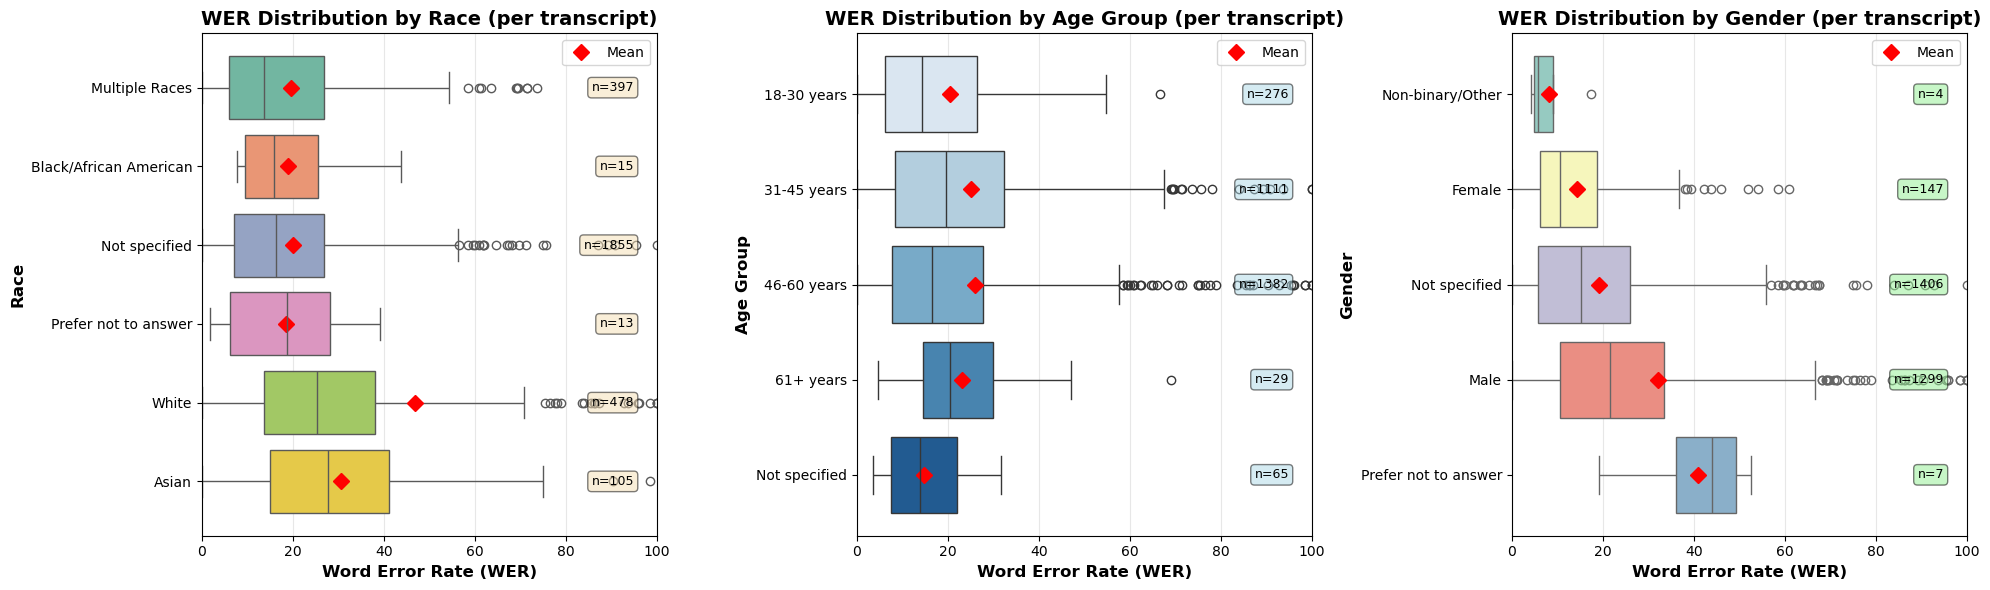


Saved: /edata/obdw/sandwich_analysis_data/wer_by_demographics_boxplots.png

STATISTICAL TESTS FOR GROUP DIFFERENCES

MULTIPLE HYPOTHESIS CORRECTION APPLIED (4 tests)

Bonferroni-corrected α = 0.0125 (0.05 / 4 tests)
FDR-corrected α = 0.0125

  Test  H-statistic  p-value (uncorrected)  p-value (Bonferroni)  Significant (Bonferroni)  p-value (FDR)  Significant (FDR)
  Race   151.777295           5.586808e-31          2.234723e-30                      True   7.449078e-31               True
   Age    29.957207           4.993603e-06          1.997441e-05                      True   4.993603e-06               True
Gender   165.548532           9.434168e-35          3.773667e-34                      True   1.886834e-34               True
Gender   165.548532           9.434168e-35          3.773667e-34                      True   1.886834e-34               True

Saved: /edata/obdw/sandwich_analysis_data/wer_demographic_tests_with_correction.csv

INDIVIDUAL TEST RESULTS

Race:
  H-statistic: 

In [ ]:
# ===============================================================================
# DESCRIPTIVE WER STRATIFIED BY KEY DEMOGRAPHICS
# ===============================================================================

if 'X_stratified' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    print("="*80)
    print("DESCRIPTIVE WER STATISTICS BY DEMOGRAPHICS")
    print("="*80)
    
    # Check if WER column exists
    if 'wer' not in X_stratified.columns:
        print("WARNING: 'wer' column not found in X_stratified")
    else:
        # Remove rows with missing WER values
        wer_data = X_stratified[X_stratified['wer'].notna()].copy()
        
        print(f"\nAnalyzing {len(wer_data)} participants with valid WER data")
        print(f"Overall WER: Mean={wer_data['wer'].mean():.3f}, Median={wer_data['wer'].median():.3f}, SD={wer_data['wer'].std():.3f}")
        
        # -----------------------------------------------------------------------
        # 1. WER BY RACE
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("1. WER BY RACE")
        print("="*80)
        
        # Get race columns and decode
        race_cols = [col for col in wer_data.columns if col.startswith('race_')]
        
        if race_cols:
            # Create race category from one-hot encoding
            def get_race_category(row):
                for col in race_cols:
                    if row[col] == 1:
                        race_code = col.replace('race_', '')
                        race_map = {
                            '2.0': 'White',
                            '4.0': 'Black/African American', 
                            '5.0': 'Asian',
                            '6.0': 'Multiple Races',
                            '999.0': 'Prefer not to answer'
                        }
                        return race_map.get(race_code, f'Race {race_code}')
                return 'Not specified'
            
            wer_data['race_category'] = wer_data.apply(get_race_category, axis=1)
            
            # Calculate statistics by race
            race_stats = wer_data.groupby('race_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            print("\nWER Statistics by Race:")
            print(race_stats)
            
            # Save to CSV
            race_stats.to_csv(out_folder + "wer_by_race_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_race_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # 2. WER BY AGE BIN
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("2. WER BY AGE BIN")
        print("="*80)
        
        # Get age columns and decode
        age_cols = [col for col in wer_data.columns if col.startswith('binned_age_')]
        
        if age_cols:
            # Create age category from one-hot encoding
            def get_age_category(row):
                for col in age_cols:
                    if row[col] == 1:
                        age_code = col.replace('binned_age_', '').replace('.0', '')
                        age_map = {
                            '1': '18-30 years',
                            '2': '31-45 years',
                            '3': '46-60 years',
                            '4': '61+ years'
                        }
                        return age_map.get(age_code, f'Age bin {age_code}')
                return 'Not specified'
            
            wer_data['age_category'] = wer_data.apply(get_age_category, axis=1)
            
            # Calculate statistics by age
            age_stats = wer_data.groupby('age_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            # Reorder by age
            age_order = ['18-30 years', '31-45 years', '46-60 years', '61+ years', 'Not specified']
            age_stats = age_stats.reindex([cat for cat in age_order if cat in age_stats.index])
            
            print("\nWER Statistics by Age Group:")
            print(age_stats)
            
            # Save to CSV
            age_stats.to_csv(out_folder + "wer_by_age_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_age_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # 3. WER BY GENDER
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("3. WER BY GENDER")
        print("="*80)
        
        # Get gender columns and decode
        gender_cols = [col for col in wer_data.columns if col.startswith('gender_')]
        
        if gender_cols:
            # Create gender category from one-hot encoding
            def get_gender_category(row):
                for col in gender_cols:
                    if row[col] == 1:
                        gender_code = col.replace('gender_', '')
                        gender_map = {
                            '2.0': 'Male',
                            '3.0': 'Female',
                            '4.0': 'Non-binary/Other',
                            '5.0': 'Prefer not to answer'
                        }
                        return gender_map.get(gender_code, f'Gender {gender_code}')
                return 'Not specified'
            
            #ToDo: change to use the AVGH decodeing function instead of hardcoding the map here
            wer_data['gender_category'] = wer_data.apply(get_gender_category, axis=1)
            
            # Calculate statistics by gender
            gender_stats = wer_data.groupby('gender_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            print("\nWER Statistics by Gender:")
            print(gender_stats)
            
            # Save to CSV
            gender_stats.to_csv(out_folder + "wer_by_gender_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_gender_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # VISUALIZATIONS: BOXPLOTS
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("CREATING WER BOXPLOT VISUALIZATIONS")
        print("="*80)
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Plot 1: WER by Race
        if 'race_category' in wer_data.columns:
            ax = axes[0]
            
            # Sort by median WER
            race_order = wer_data.groupby('race_category')['wer'].median().sort_values().index
            
            sns.boxplot(data=wer_data, y='race_category', x='wer', 
                       order=race_order, ax=ax, palette='Set2')
            
            # Add mean markers
            means = wer_data.groupby('race_category')['wer'].mean()
            for i, race in enumerate(race_order):
                ax.plot(means[race], i, 'D', markersize=8, color='red', 
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Race', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Race (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, race in enumerate(race_order):
                count = len(wer_data[wer_data['race_category'] == race])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}', 
                       ha='right', va='center', fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 2: WER by Age
        if 'age_category' in wer_data.columns:
            ax = axes[1]
            
            # Use predefined age order
            age_order_plot = [cat for cat in age_order if cat in wer_data['age_category'].unique()]
            
            sns.boxplot(data=wer_data, y='age_category', x='wer',
                       order=age_order_plot, ax=ax, palette='Blues')
            
            # Add mean markers
            means = wer_data.groupby('age_category')['wer'].mean()
            for i, age in enumerate(age_order_plot):
                ax.plot(means[age], i, 'D', markersize=8, color='red',
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Age Group', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Age Group (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, age in enumerate(age_order_plot):
                count = len(wer_data[wer_data['age_category'] == age])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}',
                       ha='right', va='center', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Plot 3: WER by Gender
        if 'gender_category' in wer_data.columns:
            ax = axes[2]
            
            # Sort by median WER
            gender_order = wer_data.groupby('gender_category')['wer'].median().sort_values().index
            
            sns.boxplot(data=wer_data, y='gender_category', x='wer',
                       order=gender_order, ax=ax, palette='Set3')
            
            # Add mean markers
            means = wer_data.groupby('gender_category')['wer'].mean()
            for i, gender in enumerate(gender_order):
                ax.plot(means[gender], i, 'D', markersize=8, color='red',
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Gender', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Gender (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, gender in enumerate(gender_order):
                count = len(wer_data[wer_data['gender_category'] == gender])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}',
                       ha='right', va='center', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(out_folder + "wer_by_demographics_boxplots.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nSaved: {out_folder}wer_by_demographics_boxplots.png")
        
        # -----------------------------------------------------------------------
        # STATISTICAL TESTS WITH MULTIPLE HYPOTHESIS CORRECTION
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("STATISTICAL TESTS FOR GROUP DIFFERENCES")
        print("="*80)
        
        from scipy import stats
        from statsmodels.stats.multitest import multipletests
        
        # Collect all p-values for correction
        test_names = []
        p_values = []
        h_statistics = []
        
        # Test 1: WER differences by Race (Kruskal-Wallis for non-parametric)
        if 'race_category' in wer_data.columns:
            race_groups = [group['wer'].values for name, group in wer_data.groupby('race_category')]
            if len(race_groups) > 1:
                h_stat, p_value = stats.kruskal(*race_groups)
                test_names.append('Race')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 2: WER differences by Age (Kruskal-Wallis)
        if 'age_category' in wer_data.columns:
            age_groups = [group['wer'].values for name, group in wer_data.groupby('age_category')]
            if len(age_groups) > 1:
                h_stat, p_value = stats.kruskal(*age_groups)
                test_names.append('Age')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 3: WER differences by Gender (Kruskal-Wallis)
        if 'gender_category' in wer_data.columns:
            gender_groups = [group['wer'].values for name, group in wer_data.groupby('gender_category')]
            if len(gender_groups) > 1:
                h_stat, p_value = stats.kruskal(*gender_groups)
                test_names.append('Gender')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 4: WER by SVI
        if 'gender_category' in wer_data.columns:
            gender_groups = [group['wer'].values for name, group in wer_data.groupby('gender_category')]
            if len(gender_groups) > 1:
                h_stat, p_value = stats.kruskal(*gender_groups)
                test_names.append('Gender')
                p_values.append(p_value)
                h_statistics.append(h_stat)

                
        # Apply multiple hypothesis corrections
        if len(p_values) > 0:
            # Bonferroni correction (most conservative)
            bonferroni_reject, bonferroni_p, _, bonferroni_alpha = multipletests(
                p_values, alpha=0.05, method='bonferroni'
            )
            
            # Benjamini-Hochberg FDR correction (controls false discovery rate)
            fdr_reject, fdr_p, _, fdr_alpha = multipletests(
                p_values, alpha=0.05, method='fdr_bh'
            )
            
            # Create results table
            results_df = pd.DataFrame({
                'Test': test_names,
                'H-statistic': h_statistics,
                'p-value (uncorrected)': p_values,
                'p-value (Bonferroni)': bonferroni_p,
                'Significant (Bonferroni)': bonferroni_reject,
                'p-value (FDR)': fdr_p,
                'Significant (FDR)': fdr_reject
            })
            
            print(f"\n{'='*80}")
            print(f"MULTIPLE HYPOTHESIS CORRECTION APPLIED ({len(p_values)} tests)")
            print(f"{'='*80}")
            print(f"\nBonferroni-corrected α = {bonferroni_alpha:.4f} (0.05 / {len(p_values)} tests)")
            print(f"FDR-corrected α = {fdr_alpha:.4f}")
            print(f"\n{results_df.to_string(index=False)}")
            
            # Save results table
            results_df.to_csv(out_folder + "wer_demographic_tests_with_correction.csv", index=False)
            print(f"\nSaved: {out_folder}wer_demographic_tests_with_correction.csv")
            
            # Print individual test interpretations
            print(f"\n{'='*80}")
            print("INDIVIDUAL TEST RESULTS")
            print(f"{'='*80}")
            
            for i, test_name in enumerate(test_names):
                print(f"\n{test_name}:")
                print(f"  H-statistic: {h_statistics[i]:.3f}")
                print(f"  p-value (uncorrected): {p_values[i]:.4f}")
                print(f"  p-value (Bonferroni): {bonferroni_p[i]:.4f}")
                print(f"  p-value (FDR): {fdr_p[i]:.4f}")
                
                if bonferroni_reject[i]:
                    print(f"  ✓ Significant after Bonferroni correction (p < {bonferroni_alpha:.4f})")
                else:
                    print(f"  ✗ Not significant after Bonferroni correction (p >= {bonferroni_alpha:.4f})")
                
                if fdr_reject[i]:
                    print(f"  ✓ Significant after FDR correction (p < {fdr_alpha:.4f})")
                else:
                    print(f"  ✗ Not significant after FDR correction (p >= {fdr_alpha:.4f})")
        else:
            print("\nNo statistical tests were performed.")
        
        print("\n" + "="*80)
        print("DESCRIPTIVE WER ANALYSIS COMPLETE")
        print("="*80)
        print("\nFiles created:")
        print(f"  - {out_folder}wer_by_race_descriptives.csv")
        print(f"  - {out_folder}wer_by_age_descriptives.csv")
        print(f"  - {out_folder}wer_by_gender_descriptives.csv")
        print(f"  - {out_folder}wer_by_demographics_boxplots.png")

else:
    print("ERROR: X_stratified not found. Please run the stratification cell first.")

Loaded transcript_df shape: (2863, 154)
Transcript rows: 2,863
Unique participants (pid): 275


,race,n
0,1.0,170
1,2.0,58
2,6.0,36
3,5.0,4
4,4.0,4
5,999.0,3


,gender,n
0,1.0,151
1,2.0,117
2,3.0,5
3,4.0,1
4,5.0,1


,age,n
0,33.0,16
1,38.0,14
2,45.0,11
3,43.0,10
4,44.0,10
5,37.0,9
6,46.0,9
7,55.0,9
8,28.0,9
9,34.0,8


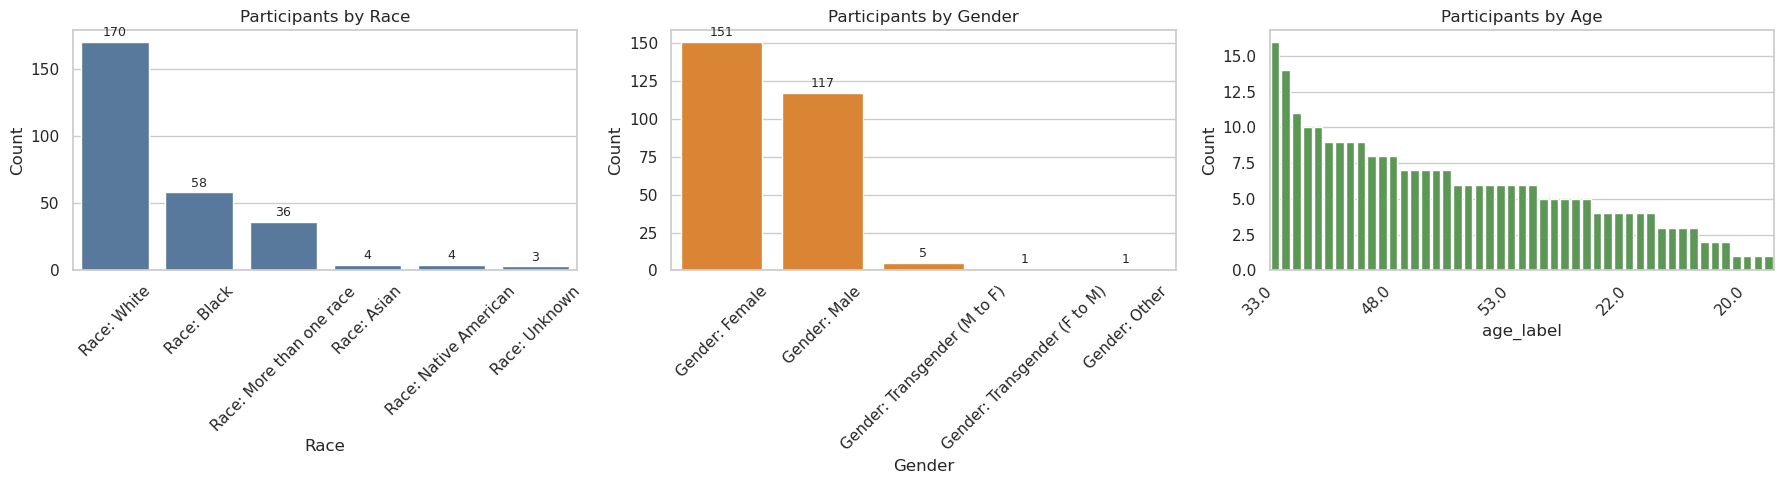

,Gender,Transcript Count,% of total transcripts,Participant Count,% of total participants,Transcripts per Participant
0,Gender: Female,1406,49.1,151,54.9,9.31
1,Gender: Male,1299,45.4,117,42.5,11.10
4,Gender: Transgender (M to F),147,5.1,5,1.8,29.40
2,Gender: Other,7,0.2,1,0.4,7.00
3,Gender: Transgender (F to M),4,0.1,1,0.4,4.00


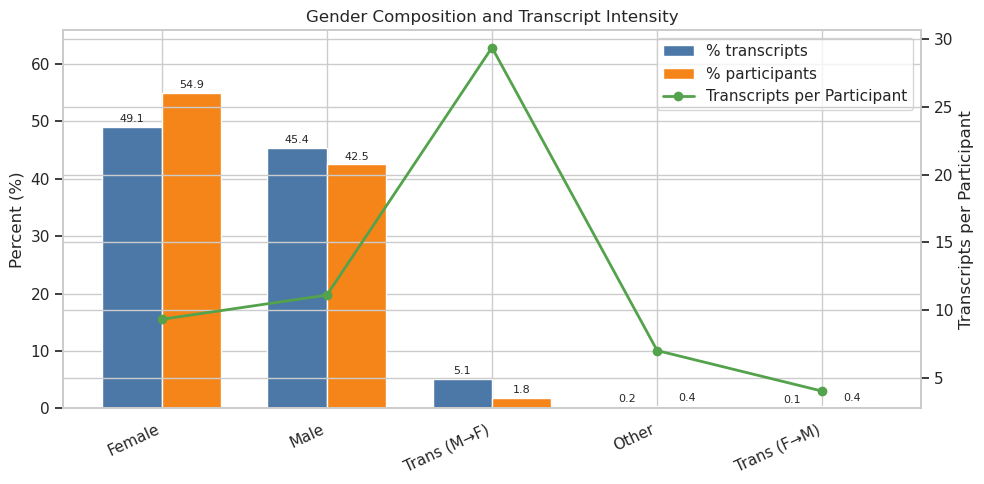

,Race,Transcript Count,Participant Count,% of total transcripts,% of total participants,Transcripts per Participant
0,1.0,1855,170,64.8,61.8,10.91
1,2.0,478,58,16.7,21.1,8.24
4,6.0,397,36,13.9,13.1,11.03
3,5.0,105,4,3.7,1.5,26.25
2,4.0,15,4,0.5,1.5,3.75


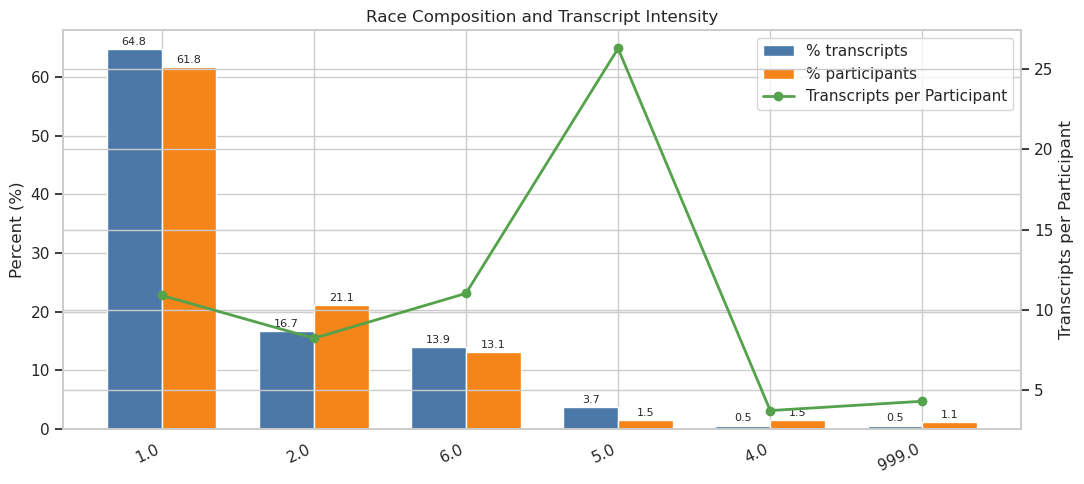

In [ ]:
# --- Rollup transcripts to participant-level and summarize demographics ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Use location-encoded data (df first, file fallback)
if "location_encoded_df" in globals():
    transcript_df = location_encoded_df.copy()
elif "location_encoded_analysis_df" in globals():
    transcript_df = location_encoded_analysis_df.copy()
else:
    transcript_df = pd.read_csv(
        "/edata/obdw/sandwich_analysis_data/main_merged_sandwich_analysis_data.csv"
    ).copy()

print(f"Loaded transcript_df shape: {transcript_df.shape}")

# 2) Resolve likely column names
def pick_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

pid_col = pick_col(transcript_df.columns, ["pid", "participant_id", "PID"])
race_col = pick_col(transcript_df.columns, ["race", "race_encoded", "race_cat"])
gender_col = pick_col(transcript_df.columns, ["gender", "gender_encoded", "sex"])
age_col = pick_col(transcript_df.columns, ["binned_age", "age_bin", "age_group", "age"])

required = {"pid": pid_col, "race": race_col, "gender": gender_col, "age": age_col}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(transcript_df.columns)}")

# 3) Participant-level rollup (one row per pid)
# Use first non-null value for each demographic field
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

participant_rollup = (
    transcript_df
    .groupby(pid_col, as_index=False)
    .agg({
        race_col: first_non_null,
        gender_col: first_non_null,
        age_col: first_non_null
    })
    .rename(columns={
        pid_col: "pid",
        race_col: "race",
        gender_col: "gender",
        age_col: "age"
    })
)

print(f"Transcript rows: {len(transcript_df):,}")
print(f"Unique participants (pid): {participant_rollup['pid'].nunique():,}")

# 4) Count tables
race_counts = participant_rollup["race"].value_counts(dropna=False).rename_axis("race").reset_index(name="n")
gender_counts = participant_rollup["gender"].value_counts(dropna=False).rename_axis("gender").reset_index(name="n")
age_counts = participant_rollup["age"].value_counts(dropna=False).rename_axis("age").reset_index(name="n")

display(race_counts, gender_counts, age_counts)

# 5) Optional decode labels if safe_decode exists
# 5) Decode labels robustly (works for raw coded values and already-decoded strings)
import pandas as pd

def decode_with_prefix(val, prefix):
    if pd.isna(val):
        return "Missing"

    s = str(val).strip()

    # If value already looks like text (not a numeric code), keep it
    if not s.replace(".", "", 1).isdigit():
        return s

    # Try common coded-key formats that safe_decode may expect
    candidates = [f"{prefix}_{s}"]
    try:
        f = float(s)
        candidates += [f"{prefix}_{f:.1f}", f"{prefix}_{int(f)}"]
    except Exception:
        pass

    # Fallback attempts
    candidates += [s, val]

    for c in candidates:
        try:
            out = safe_decode(c)
            # Accept only if decode changed the value meaningfully
            if out is not None and str(out).strip() not in {"", str(c)}:
                return str(out)
        except Exception:
            pass

    # Final fallback
    return s

plot_df = participant_rollup.copy()
plot_df["race_label"] = plot_df["race"].apply(lambda x: decode_with_prefix(x, "race"))
plot_df["gender_label"] = plot_df["gender"].apply(lambda x: decode_with_prefix(x, "gender"))
plot_df["age_label"] = plot_df["age"].apply(lambda x: decode_with_prefix(x, "age"))


# 6) Graphs (similar style: simple count bars)
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=plot_df, x="race_label", order=plot_df["race_label"].value_counts().index, ax=axes[0], color="#4c78a8")
axes[0].set_title("Participants by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=plot_df, x="gender_label", order=plot_df["gender_label"].value_counts().index, ax=axes[1], color="#f58518")
axes[1].set_title("Participants by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(
    data=plot_df,
    x="age_label",
    order=plot_df["age_label"].value_counts().index,
    ax=axes[2],
    color="#54a24b"
)
axes[2].set_title("Participants by Age")
axes[2].set_ylabel("Count")
#axes[2].set_xlabel("")  # remove x-axis label text
# keep only ~4 x tick labels visible
ticks = axes[2].get_xticks()
labels = [t.get_text() for t in axes[2].get_xticklabels()]
step = max(1, len(labels) // 4)

axes[2].set_xticks(ticks)
axes[2].set_xticklabels(
    [lab if i % step == 0 else "" for i, lab in enumerate(labels)],
    rotation=45, ha="right"
)

# Add bar labels
for i, ax in enumerate(axes):
    if i == 2:  # skip Participants by Age
        continue
    for c in ax.containers:
        ax.bar_label(c, fmt="%d", padding=2, fontsize=9)


plt.tight_layout()
plt.show()

# ToDo: delete, checking data integrity
# Gender summary with Count, % of total, and Transcript-per-Participant ratio
import pandas as pd
import numpy as np

# Optional: decode gender labels
def gender_label(x):
    try:
        return safe_decode(f"gender_{x}") if pd.notna(x) else "Missing"
    except Exception:
        return "Missing" if pd.isna(x) else str(x)

# 1) Transcript-level counts
t = (
    transcript_df.assign(Gender=transcript_df["gender"].apply(gender_label))
    .groupby("Gender", dropna=False)
    .size()
    .reset_index(name="Transcript Count")
)

# 2) Participant-level counts
p = (
    participant_rollup.assign(Gender=participant_rollup["gender"].apply(gender_label))
    .groupby("Gender", dropna=False)
    .size()
    .reset_index(name="Participant Count")
)

# Merge and compute requested metrics
gender_summary = t.merge(p, on="Gender", how="outer").fillna(0)
gender_summary["Transcript Count"] = gender_summary["Transcript Count"].astype(int)
gender_summary["Participant Count"] = gender_summary["Participant Count"].astype(int)

total_transcripts = gender_summary["Transcript Count"].sum()
total_participants = gender_summary["Participant Count"].sum()

gender_summary["% of total transcripts"] = (
    100 * gender_summary["Transcript Count"] / total_transcripts
).round(1)
gender_summary["% of total participants"] = (
    100 * gender_summary["Participant Count"] / total_participants
).round(1)

# Transcripts Count for each gender / Participant Count for each gender
gender_summary["Transcripts per Participant"] = np.where(
    gender_summary["Participant Count"] > 0,
    (gender_summary["Transcript Count"] / gender_summary["Participant Count"]).round(2),
    np.nan
)

# Final display columns
gender_summary = gender_summary[
    [
        "Gender",
        "Transcript Count",
        "% of total transcripts",
        "Participant Count",
        "% of total participants",
        "Transcripts per Participant",
    ]
].sort_values("Transcript Count", ascending=False)

display(gender_summary)

#ToDo: data check, possibly delete
import matplotlib.pyplot as plt
import numpy as np

# assumes your dataframe is named gender_summary
plot_df = gender_summary.copy()

# optional: shorten labels
plot_df["Gender_short"] = (
    plot_df["Gender"]
    .str.replace("Gender: ", "", regex=False)
    .str.replace("Transgender (M to F)", "Trans (M→F)", regex=False)
    .str.replace("Transgender (F to M)", "Trans (F→M)", regex=False)
)

x = np.arange(len(plot_df))
w = 0.36

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars for percentages
b1 = ax1.bar(
    x - w/2, plot_df["% of total transcripts"], width=w, label="% transcripts", color="#4c78a8"
)
b2 = ax1.bar(
    x + w/2, plot_df["% of total participants"], width=w, label="% participants", color="#f58518"
)

ax1.set_ylabel("Percent (%)")
ax1.set_ylim(0, max(plot_df["% of total transcripts"].max(), plot_df["% of total participants"].max()) * 1.2)
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["Gender_short"], rotation=25, ha="right")
ax1.set_title("Gender Composition and Transcript Intensity")

# Line for transcripts per participant
ax2 = ax1.twinx()
ax2.plot(
    x, plot_df["Transcripts per Participant"], color="#54a24b", marker="o", linewidth=2,
    label="Transcripts per Participant"
)
ax2.set_ylabel("Transcripts per Participant")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

# Optional labels on bars
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

# 1) Ensure transcript_df exists (set this to your source df if needed)
# transcript_df = analysis_df.copy()

# 2) Ensure participant_rollup exists
if "participant_rollup" not in globals():
    # pick likely column names
    pid_col = "pid" if "pid" in transcript_df.columns else "participant_id"
    race_col = "race" if "race" in transcript_df.columns else "race_encoded"

    def first_non_null(s):
        s = s.dropna()
        return s.iloc[0] if len(s) else pd.NA

    participant_rollup = (
        transcript_df.groupby(pid_col, as_index=False)
        .agg({race_col: first_non_null})
        .rename(columns={pid_col: "pid", race_col: "race"})
    )

# 3) Build race_summary
t = (
    transcript_df.assign(race=transcript_df["race"] if "race" in transcript_df.columns else transcript_df["race_encoded"])
    .groupby("race", dropna=False)
    .size()
    .reset_index(name="Transcript Count")
)

p = (
    participant_rollup.groupby("race", dropna=False)
    .size()
    .reset_index(name="Participant Count")
)

race_summary = t.merge(p, on="race", how="outer").fillna(0)
race_summary["Transcript Count"] = race_summary["Transcript Count"].astype(int)
race_summary["Participant Count"] = race_summary["Participant Count"].astype(int)

race_summary["% of total transcripts"] = (
    100 * race_summary["Transcript Count"] / race_summary["Transcript Count"].sum()
).round(1)
race_summary["% of total participants"] = (
    100 * race_summary["Participant Count"] / race_summary["Participant Count"].sum()
).round(1)
race_summary["Transcripts per Participant"] = np.where(
    race_summary["Participant Count"] > 0,
    (race_summary["Transcript Count"] / race_summary["Participant Count"]).round(2),
    np.nan
)

race_summary = race_summary.rename(columns={"race": "Race"}).sort_values("Transcript Count", ascending=False)
display(race_summary.head())

# Graph from race_summary (Composition + Transcript Intensity)
import matplotlib.pyplot as plt
import numpy as np

# Make sure race_summary exists
plot_df = race_summary.copy()

# Optional label cleanup
plot_df["Race_short"] = plot_df["Race"].astype(str).str.replace("Race: ", "", regex=False)

x = np.arange(len(plot_df))
w = 0.36

fig, ax1 = plt.subplots(figsize=(11, 5))

# Bars
bars1 = ax1.bar(
    x - w/2, plot_df["% of total transcripts"], width=w,
    color="#4c78a8", label="% transcripts"
)
bars2 = ax1.bar(
    x + w/2, plot_df["% of total participants"], width=w,
    color="#f58518", label="% participants"
)

ax1.set_title("Race Composition and Transcript Intensity")
ax1.set_ylabel("Percent (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["Race_short"], rotation=25, ha="right")

# Line on secondary axis
ax2 = ax1.twinx()
ax2.plot(
    x, plot_df["Transcripts per Participant"],
    color="#54a24b", marker="o", linewidth=2,
    label="Transcripts per Participant"
)
ax2.set_ylabel("Transcripts per Participant")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

# Optional bar labels
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax1.text(b.get_x() + b.get_width()/2, h + 0.4, f"{h:.1f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
